Copyright 2025. Jungwoo Kim. All rights reserved.<br>
Complex System Design Laboratory<br>
Dept. of Industrial & Systems Engineering, KAIST

# Import Libraries

In [67]:
import numpy as np
import time  # 2026-09-04: run_simulation 구간별 실행시간 profiling을 위한 타이머 모듈
from tqdm import tqdm
import random
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import easydict
from scipy.spatial.distance import euclidean
from scipy.spatial import distance_matrix
from scipy.interpolate import griddata
from shapely.geometry import Point, MultiPolygon, Polygon
import geopandas as gpd
import openpyxl
from easydict import EasyDict
from tqdm import tqdm
from sklearn.neighbors import KDTree
from descartes import PolygonPatch
import matplotlib.colors as mcolors
from pyproj import Proj, transform
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

proj_tm_mid = Proj(init='epsg:2097')
proj_wgs84 = Proj(init='epsg:4326')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
random.seed(4242)

# Tool Functions

In [68]:
def random_points_in_multipolygon(shape, num_points):
    if isinstance(shape, Polygon):
        min_x, min_y, max_x, max_y = shape.bounds
    else:
        min_x, min_y, max_x, max_y = shape.geoms[0].bounds
        for i in range(1,len(shape.geoms)):
            polygon = shape.geoms[i]
            min_x_i, min_y_i, max_x_i, max_y_i = polygon.bounds
            if min_x_i<min_x:
                min_x = min_x_i
            if min_y_i<min_y:
                min_y = min_y_i
            if max_x_i>max_x:
                max_x = max_x_i
            if max_y_i>max_y:
                max_y = max_y_i
    # 좌표 설정
    points = []
    while len(points) < num_points:
        point = Point(random.uniform(min_x, max_x), random.uniform(min_y, max_y))
        if isinstance(shape, Polygon):
            if shape.contains(point):
                    points.append(point)
        else:
            for i in range(len(shape.geoms)):
                polygon = shape.geoms[i]
                if polygon.contains(point):
                    points.append(point)
            
    return points

# Geographical Setting

c:\Users\user\Desktop\대학원\기초연구실\ABM code\Outmigration_ABM\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from euc-kr to UTF-8.  This warning will not be emitted anymore
  return ogr_read(
c:\Users\user\Desktop\대학원\기초연구실\ABM code\Outmigration_ABM\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Korea_shapefiles/TL_SCCO_CTPRVN.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


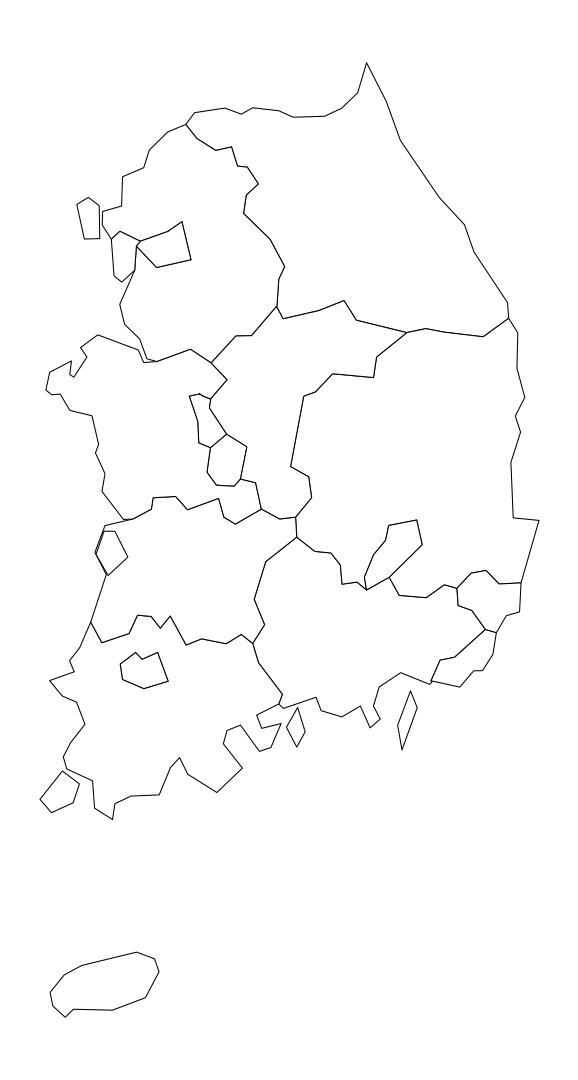

In [69]:
# shp 파일 로드
# filepath_shp_simplified = '/Users/jungwoo/Library/Mobile Documents/com~apple~CloudDocs/Research Project/Assets/shapefiles_korea_simplified/TL_SCCO_CTPRVN/'
geo_file = 'Korea_shapefiles/TL_SCCO_CTPRVN.shp'
gdf = gpd.read_file(geo_file, encoding='euc-kr')
outside_polygon_mask = np.load("outside_polygon_mask.npy")

gdf.CTP_KOR_NM = [
    '강원',
    '경기',
    '경남',
    '경북',
    '광주',
    '대구',
    '대전',
    '부산',
    '서울',
    '세종',
    '울산',
    '인천',
    '전남',
    '전북',
    '제주',
    '충남',
    '충북'
]

# Manual modifications

coords1 = [(126.59156455632241, 37.593011823985485), (126.6512526639701, 37.63798791865732),
           (126.79369544519706, 37.58159385885768), (126.7662043574505, 37.554242375748366),
           (126.7544652746883, 37.41757293948264), (126.66344966004381, 37.35053506629968),
           (126.60996708541704, 37.38718717658724), (126.59156455632241, 37.593011823985485)]
coords2 = [(126.43121685572747, 37.82986908194544), (126.35057985274231, 37.789565062650894),
           (126.40316813158975, 37.59428252797514), (126.51062866491168, 37.59662373953827),
           (126.5068975008081, 37.78234762310096), (126.43121685572747, 37.82986908194544)]
polygon1 = Polygon(coords1)
polygon2 = Polygon(coords2)
gdf.loc[11,'geometry'] = MultiPolygon([polygon1, polygon2])
coords1 = [(126.16122307201523, 36.84077447960923), (126.1346055789919, 36.740324711760486),
           (126.17654567314271, 36.71395826078249), (126.23492459115923, 36.71807007755431),
           (126.30206037378963, 36.62590094644257), (126.45646406403513, 36.595210697608685),
           (126.50292188756616, 36.43400816610959), (126.48058601093365, 36.38503110228303),
           (126.54732360572413, 36.2683451886003), (126.52610700099113, 36.167672899104176),
           (126.67649645277267, 36.00923289097959), (126.74156052854424, 36.0119448809583),
           (126.87081796412734, 36.06740464723523), (126.88282411119397, 36.13207402130215),
           (127.04003005195446, 36.13933847885477), (127.12318778724037, 36.06424768168607),
           (127.34009324309051, 36.128979280260644), (127.37649530932696, 36.02288908915842),
           (127.45674606514737, 35.983276216973415), (127.63829543249358, 36.06793987054469),
           (127.63791587136105, 36.06890166403231), (127.59802031438574, 36.21708890108369),
           (127.49257720191125, 36.23795395068193), (127.44871641082584, 36.19672289194393),
           (127.32394583489626, 36.203158372814976), (127.25877186484053, 36.2760505815688),
           (127.28212428234082, 36.414603964631645), (127.20138964906599, 36.44197527604719),
           (127.19378772255222, 36.564812513911036), (127.13437853561463, 36.7067919896922),
           (127.20793603234716, 36.71918904581354), (127.20792754283481, 36.71917583461923),
           (127.20792684751393, 36.71917607776152), (127.20787710929177, 36.71918850565105),
           (127.2078769797854, 36.71919046333673), (127.20787710929177, 36.71918850565105),
           (127.20792754283481, 36.71917583461923), (127.20789089293503, 36.719119287386114),
           (127.22822551880574, 36.708468998779054), (127.22822008391248, 36.70845514952263),
           (127.22822551880574, 36.708468998779054), (127.22823057936279, 36.70846556314337),
           (127.28126367067202, 36.69057059579415), (127.28125389722467, 36.69051337150437),
           (127.28126367067202, 36.69057059579415), (127.28127028658162, 36.69055905464245),
           (127.28529006643944, 36.690671454249056), (127.39951636598008, 36.7992190104284),
           (127.28782886465115, 36.893778879374906), (127.14366362142856, 36.97105116272797),
           (126.90970519398604, 36.90160135376443), (126.8169656460083, 36.8961446522021),
           (126.77958940321619, 36.96680085646616), (126.49675135100698, 37.052811981614845),
           (126.37649095830157, 36.9806341203674), (126.42112642747156, 36.92727201106454),
           (126.32973391103106, 36.81358358482278), (126.30162178982232, 36.82841928228409),
           (126.31328915259776, 36.90549865703278), (126.16122307201523, 36.84077447960923)]
gdf.loc[15,'geometry'] = Polygon(coords1)

# Visualize
fig, ax = plt.subplots(figsize=(10, 7), 
                           gridspec_kw={'left': 0, 'right': 1, 'bottom': 0, 'top': 1}, 
                           dpi=150)
gdf.plot(ax=ax, color='w', linewidth=0.5, edgecolor='black', alpha=1)
ax.axis('off')
plt.show()

# Class codes

## Class Simulation

In [70]:
class Simulation:
    def __init__(self, parameter_set):
        self.parameter_set = parameter_set
        self.df_city_info = parameter_set.df_city_info
        self.df_hospital_crd = parameter_set.df_hospital_crd

        self.num_population = sum(self.parameter_set.df_city_info[self.parameter_set.target_population_column])
        self.num_hospital = sum(self.parameter_set.df_city_info['NUM_HOSPITAL'])

        self.arr_population_PHQ = np.full((self.num_population,self.num_hospital), -1.0)
        self.arr_population_PRQ = np.full((self.num_population,len(self.parameter_set.dict_parameter_initial_PRQ)), -1.0)
        self.arr_population_choice_prob = np.zeros((self.num_population,self.num_hospital))  # [2026-09-07 calculate choice probability]: Simulation-level choice probability 공유 배열
        self.arr_population_CancerOrNot = np.full(self.num_population, False)

        self.max_quality = parameter_set.max_quality
        self.min_quality = parameter_set.min_quality

    def initialize(self):
        self.create_Cities()
        self.create_Hospitals()
        self.create_People()
        self.set_population_regions()  # [2026-09-07 WOM]: N_r 계산에 사용할 person별 region index를 초기화 시 한 번만 생성
        self.set_person_neighbors()
        self.set_population_WOM_arrays()  # [2026-09-07 WOM]: Simulation-level WOM 계산용 neighbor edge 배열 초기화

    def execute(self):
        self.set_OHQ()
        self.set_person_initial_perception()
        self.create_Archive()
        self.run_simulation()

    def create_Cities(self):
        self.arr_City_NM = self.df_city_info.SIDO_NM.values
        self.arr_City = np.array([])

        for idx_city in range(len(self.arr_City_NM)):
            nm_city = self.arr_City_NM[idx_city]
            df_city_parameter = self.df_city_info.loc[self.df_city_info.SIDO_NM == nm_city]
            parameter_set_city = EasyDict({
                'idx_city' : idx_city,
                'nm_city' : nm_city,

                'population_real' : df_city_parameter.POPULATION_REAL.values[0],
                'num_population' : df_city_parameter[self.parameter_set.target_population_column].values[0],
                'num_hospital' : df_city_parameter.NUM_HOSPITAL.values[0],
                'nm_region' : df_city_parameter.REGION.values[0],
                })
            self.arr_City = np.append(self.arr_City, City(parameter_set_city))
    
    def create_Hospitals(self):
        self.arr_Hospital = np.array([])
        self.df_Hospital_info = pd.DataFrame({'idx_hospital' : range(self.df_city_info.NUM_HOSPITAL.sum())})
        self.df_Hospital_info['nm_city'] = ''
        self.df_Hospital_info['idx_city'] = 0
        self.df_Hospital_info['coord'] = Point(0,0)
        self.df_Hospital_info['OQ_objective_quality'] = -1.0

        idx_hospital = 0
        self.idx_hospital_in_region = [[],[],[],[],[]]

        for idx_city in range(len(self.arr_City_NM)):
            nm_city = self.arr_City_NM[idx_city]
            df_hospital_crd_city = self.df_hospital_crd.loc[self.df_hospital_crd.SIDO_NM == nm_city]
            arr_idx_hospital_incity = np.array([], dtype=int)

            for idx_hospital_incity in range(self.arr_City[idx_city].num_hospital):
                nm_hospital = df_hospital_crd_city.iloc[idx_hospital_incity].INST_NM
                hospital_crd = Point(transform(proj_tm_mid, proj_wgs84, 
                                              df_hospital_crd_city.iloc[idx_hospital_incity].loc['CRD_X'], 
                                              df_hospital_crd_city.iloc[idx_hospital_incity].loc['CRD_Y']))
                parameter_set_hospital = EasyDict({
                    'idx_hospital' : idx_hospital,
                    'nm_hospital' : nm_hospital,
                    'idx_city' : idx_city,
                    'nm_city' : nm_city,
                    'nm_hospital' : nm_hospital,
                    'coord' : hospital_crd
                    })
                self.arr_Hospital = np.append(self.arr_Hospital, Hospital(parameter_set_hospital))
                arr_idx_hospital_incity = np.append(arr_idx_hospital_incity, idx_hospital)

                self.df_Hospital_info.loc[idx_hospital, 'nm_hospital'] = nm_hospital
                self.df_Hospital_info.loc[idx_hospital, 'nm_city'] = nm_city
                self.df_Hospital_info.loc[idx_hospital, 'idx_city'] = idx_city
                self.df_Hospital_info.loc[idx_hospital, 'coord'] = hospital_crd
                idx_hospital += 1

            self.arr_City[idx_city].arr_idx_hospital_incity = arr_idx_hospital_incity
        
        self.df_Hospital_info = pd.merge(self.df_Hospital_info, self.df_city_info[['SIDO_NM', 'REGION']], how='left', left_on = 'nm_city', right_on = 'SIDO_NM')
        region_mapping = {}
        for idx in range(len(self.parameter_set.dict_parameter_initial_PRQ)):
            region_mapping[list(self.parameter_set.dict_parameter_initial_PRQ.keys())[idx]] = idx
        self.df_Hospital_info['idx_REGION'] = self.df_Hospital_info['REGION'].map(region_mapping)

        for idx_REGION in range(len(region_mapping.keys())):
            self.idx_hospital_in_region[idx_REGION] = self.df_Hospital_info.loc[self.df_Hospital_info.idx_REGION == idx_REGION, 'idx_hospital'].values

        # [2026-09-07 calculate choice probability]: choice probability vectorization에 사용할 고정 hospital-region index
        self.arr_hospital_region = self.df_Hospital_info.idx_REGION.values.astype(int)
        self.idx_representative_hospital_by_region = np.array([
            idx_hospital[0] for idx_hospital in self.idx_hospital_in_region
        ])
        self.num_region = len(self.idx_hospital_in_region)
    
    def create_People(self):
        self.arr_Person = np.array([])

        self.df_Person_info = pd.DataFrame({'idx_person' : range(self.df_city_info[self.parameter_set.target_population_column].sum())})
        self.df_Person_info['nm_city'] = ''
        self.df_Person_info['idx_city'] = 0
        self.df_Person_info['coord'] = Point(0,0)
        self.df_Person_info['is_cancerpatient'] = False
        self.df_Person_info['idx_chosen_hospital'] = -1
        self.df_Person_info['idx_region_chosen_hospital'] = -1
        self.set_base_PHQ()
        idx_person = 0

        for idx_city in range(len(self.arr_City_NM)):
            nm_city = self.arr_City_NM[idx_city]
            df_city_parameter = self.df_city_info.loc[self.df_city_info.SIDO_NM == nm_city]

            arr_idx_person_incity = np.array([], dtype=int)

            geom_city = gdf.loc[gdf.CTP_KOR_NM == nm_city].iloc[0].geometry
            random_coords = random_points_in_multipolygon(gdf.loc[gdf.CTP_KOR_NM == nm_city].iloc[0].geometry, self.arr_City[idx_city].num_population)
            
            for idx_person_incity in range(self.arr_City[idx_city].num_population):
                parameter_set_person = EasyDict({                
                    'idx_person' : idx_person,
                    'is_cancerpatient' : False,
                    'is_new_cancerpatient' : False,
                    
                    'idx_city' :    idx_city,
                    'nm_city' :     nm_city,
                    'coord' :       random_coords[idx_person_incity],
                    'dict_parameter_initial_PRQ' : self.parameter_set.dict_parameter_initial_PRQ,

                    'sigma_OHQ' :   self.parameter_set.sigma_OHQ,
                    'sigma_OHQ' :   self.parameter_set.sigma_OHQ,
                    'sigma_PRQ' :   self.parameter_set.sigma_PRQ,

                    'beta_PQ' :     self.parameter_set.beta_PQ,
                    'beta_d' :      self.parameter_set.beta_d,
                    'delta' :       self.parameter_set.delta,
                    'pi' :          self.parameter_set.pi,
                    
                    'df_Hospital_info' : self.df_Hospital_info,
                    'df_Person_info' : self.df_Person_info,
                    'idx_hospital_in_region' : self.idx_hospital_in_region,
                    'arr_hospital_region' : self.arr_hospital_region,
                    'idx_representative_hospital_by_region' : self.idx_representative_hospital_by_region,

                    'arr_population_PHQ' : self.arr_population_PHQ,
                    'arr_population_PRQ' : self.arr_population_PRQ,
                    'arr_population_choice_prob' : self.arr_population_choice_prob,
                    'arr_population_CancerOrNot' : self.arr_population_CancerOrNot,

                    'base_PHQ' : self.base_PHQ
                    })
                

                self.arr_Person = np.append(self.arr_Person, Person(parameter_set_person, self.parameter_set))
                arr_idx_person_incity = np.append(arr_idx_person_incity, idx_person)
                self.df_Person_info.loc[idx_person, 'nm_city'] = nm_city
                self.df_Person_info.loc[idx_person, 'idx_city'] = idx_city
                self.df_Person_info.loc[idx_person, 'coord'] = random_coords[idx_person_incity]
                self.df_Person_info.loc[idx_person, 'is_cancerpatient'] = parameter_set_person.is_cancerpatient
                idx_person += 1
            
            # 각 도시의 인구 idx 넣어주기
            self.arr_City[idx_city].arr_idx_person_incity = arr_idx_person_incity

        self.df_Person_info = pd.merge(self.df_Person_info, 
                                       self.df_city_info[['SIDO_NM', 'REGION']],
                                       how='left', left_on = 'nm_city', right_on = 'SIDO_NM')

    # [2026-09-07 WOM]: N_r의 반복적인 DataFrame region 조회를 대체할 population-level region index
    def set_population_regions(self):
        region_mapping = {region: idx for idx, region in enumerate(self.parameter_set.dict_parameter_initial_PRQ.keys())}
        self.arr_population_region = self.df_Person_info.REGION.map(region_mapping).values
        self.idx_person_by_region = [
            np.where(self.arr_population_region == idx_region)[0]
            for idx_region in range(len(region_mapping))
        ]
        self.num_person_by_region = np.array([len(idx_person) for idx_person in self.idx_person_by_region])

    # [2026-09-07 WOM]: timestep 시작 시 region별 PRQ 평균을 한 번 계산하고, 순차 갱신을 위해 평균을 보존
    def initialize_N_indirect_from_region(self):
        self.mean_PRQ_by_region = np.array([
            np.mean(self.arr_population_PRQ[idx_person], axis=0)
            for idx_person in self.idx_person_by_region
        ])

    # [2026-09-07 WOM]: person별 N_r을 cached region 평균과 NumPy indexing으로 계산
    def get_N_indirect_from_region(self, idx_person):
        idx_region = self.arr_population_region[idx_person]
        return self.parameter_set.mu_rn * (
            self.mean_PRQ_by_region[idx_region] - self.arr_population_PRQ[idx_person]
        )

    # [2026-09-07 WOM]: 기존의 person 순차 PRQ 갱신 뒤 region 평균을 차분으로 갱신해 N_r 정의를 유지
    def update_N_indirect_from_region_mean(self, idx_person, previous_PRQ):
        idx_region = self.arr_population_region[idx_person]
        self.mean_PRQ_by_region[idx_region] += (
            self.arr_population_PRQ[idx_person] - previous_PRQ
        ) / self.num_person_by_region[idx_region]


    def create_Archive(self):
        self.achv_population_is_cancerpatient = np.full((self.parameter_set.max_dt, self.num_population), False)
        self.achv_population_is_cancerpatient[0] = self.df_Person_info.is_cancerpatient.values

        self.achv_population_choice_prob = np.full((self.parameter_set.max_dt, self.num_population, self.num_hospital), 0.0)
        self.achv_population_PRQ = np.full((self.parameter_set.max_dt, self.num_population, len(self.parameter_set.dict_parameter_initial_PRQ)), 0.0)
        self.achv_population_PHQ = np.full((self.parameter_set.max_dt, self.num_population, self.num_hospital), 0.0)
        self.achv_population_True_Utility = np.full((self.parameter_set.max_dt, self.num_population, self.num_hospital), 0.0)
        self.achv_OHQ = np.full((self.parameter_set.max_dt, self.num_hospital), 0.0)

        self.achv_population_choice_prob[0] = self.arr_population_choice_prob  # [2026-09-07 calculate choice probability]: Simulation-level choice probability archive 초기화
        for idx_person in self.df_Person_info.idx_person.values:
            self.achv_population_PRQ[0,idx_person] = self.arr_Person[idx_person].PRQ
            self.achv_population_PHQ[0,idx_person] = self.arr_Person[idx_person].PHQ
        self.achv_OHQ[0] = self.df_Hospital_info.OQ_objective_quality.values


    def update_Archive(self, dt):
        self.achv_population_is_cancerpatient[dt] = self.df_Person_info.is_cancerpatient.values
        self.achv_population_choice_prob[dt] = self.arr_population_choice_prob  # [2026-09-07 calculate choice probability]: vectorized choice probability를 archive에 저장
        for idx_person in self.df_Person_info.idx_person.values:
            self.achv_population_PRQ[dt,idx_person] = self.arr_Person[idx_person].PRQ
            self.achv_population_PHQ[dt,idx_person] = self.arr_Person[idx_person].PHQ
        self.achv_OHQ[dt] = self.df_Hospital_info.OQ_objective_quality.values

# Initial Setting
    def set_OHQ(self):
        for idx_hospital, row in self.df_Hospital_info.iterrows():
            nm_region = row['REGION']
            initial_OHQ = self.parameter_set.dict_parameter_initial_OHQ[nm_region] + np.random.normal(0, self.parameter_set.sigma_OHQ)

            self.arr_Hospital[idx_hospital].OQ_obj_quality = initial_OHQ
            self.df_Hospital_info.loc[idx_hospital, 'OQ_objective_quality'] = initial_OHQ

    def set_person_initial_perception(self):
        # 2026-09-11: 초기 PHQ/PRQ와 거리효과를 population-level NumPy 연산으로 한 번에 생성
        self.arr_population_PHQ[:] = np.clip(
            self.base_PHQ[np.newaxis, :] + np.random.normal(
                0, self.parameter_set.sigma_OHQ, (self.num_population, self.num_hospital)
            ),
            self.min_quality, self.max_quality
        )
        initial_PRQ = np.asarray(list(self.parameter_set.dict_parameter_initial_PRQ.values()))
        self.arr_population_PRQ[:] = np.clip(
            initial_PRQ[np.newaxis, :] + np.random.normal(
                0, self.parameter_set.sigma_PRQ, (self.num_population, self.num_region)
            ),
            self.min_quality, self.max_quality
        )

        # 2026-09-11: Shapely Point.distance와 동일한 평면 좌표 거리식을 broadcasting으로 계산
        person_coords = np.array([[coord.x, coord.y] for coord in self.df_Person_info.coord.values])
        hospital_coords = np.array([[coord.x, coord.y] for coord in self.df_Hospital_info.coord.values])
        region_coords = np.array([
            [self.parameter_set.dict_crd_region[region].x, self.parameter_set.dict_crd_region[region].y]
            for region in self.parameter_set.dict_parameter_initial_PRQ.keys()
        ])
        self.arr_distance_effect_hospital = np.exp(
            -self.parameter_set.delta * np.sqrt(
                np.sum((person_coords[:, np.newaxis, :] - hospital_coords[np.newaxis, :, :]) ** 2, axis=2)
            )
        )
        self.arr_distance_effect_region = np.exp(
            -self.parameter_set.delta * np.sqrt(
                np.sum((person_coords[:, np.newaxis, :] - region_coords[np.newaxis, :, :]) ** 2, axis=2)
            )
        )
        # 2026-09-11: region 거리효과(P, R)를 choice utility에서 사용할 hospital 축(P, H)으로만 매핑
        self.arr_distance_effect_region_hospital = self.arr_distance_effect_region[:, self.arr_hospital_region]

        # 2026-09-11: legacy Person API와 archive 호환에 필요한 상태만 shared population 배열의 row view로 연결
        for idx_person, person in enumerate(self.arr_Person):
            person.PHQ = self.arr_population_PHQ[idx_person]
            person.PRQ = self.arr_population_PRQ[idx_person]
            person.Q_h[0] = person.PHQ
            person.Q_r[0] = person.PRQ
            person.arr_distance_effect_hospital = self.arr_distance_effect_hospital[idx_person]
            person.arr_distance_effect_region = self.arr_distance_effect_region_hospital[idx_person]
            person.df_Person_info = self.df_Person_info

        self.calculate_choice_prob_all()

    # [2026-09-07 calculate choice probability]: 모든 person의 utility를 (P, H) NumPy 연산으로 계산
    def calculate_utility_all(self):
        arr_PRQ_hospital = self.arr_population_PRQ[:, self.arr_hospital_region]
        self.arr_utility_region = (
            arr_PRQ_hospital * self.parameter_set.beta_PQ
            + self.arr_distance_effect_region_hospital * self.parameter_set.beta_d
        )
        self.arr_utility_hospital = (
            self.arr_population_PHQ * self.parameter_set.beta_PQ
            + self.arr_distance_effect_hospital * self.parameter_set.beta_d
        )

    # [2026-09-07 calculate choice probability]: 모든 person의 2-stage/standard logit choice probability를 NumPy로 계산
    def calculate_choice_prob_all(self):
        self.calculate_utility_all()

        if self.parameter_set.pi != 0:
            exp_u_region = np.exp(self.arr_utility_region)
            regional_denominator = np.sum(
                exp_u_region[:, self.idx_representative_hospital_by_region], axis=1
            )
            self.arr_population_choice_prob_region = exp_u_region / regional_denominator[:, np.newaxis]

            exp_u_hospital = np.exp(self.arr_utility_hospital * self.parameter_set.pi)
            sum_exp_by_region = np.zeros((self.num_population, self.num_region))
            np.add.at(
                sum_exp_by_region,
                (np.arange(self.num_population)[:, np.newaxis], self.arr_hospital_region[np.newaxis, :]),
                exp_u_hospital
            )
            self.arr_population_choice_prob_hospital = (
                exp_u_hospital / sum_exp_by_region[:, self.arr_hospital_region]
            )
            self.arr_population_choice_prob[:] = (
                self.arr_population_choice_prob_region
                * self.arr_population_choice_prob_hospital
            )
        else:
            exp_u_hospital = np.exp(self.arr_utility_hospital)
            inf_mask = exp_u_hospital == np.inf
            if np.any(inf_mask):
                non_inf_mask = ~inf_mask
                if np.any(~np.any(non_inf_mask, axis=1)):
                    raise ValueError("max() arg is an empty sequence")
                first_non_inf = np.argmax(non_inf_mask, axis=1)
                replacement = exp_u_hospital[np.arange(self.num_population), first_non_inf]
                # [2026-09-07 calculate choice probability]: Python max와 같은 NaN 비교 순서를 hospital 축에서만 재현
                for idx_hospital in range(self.num_hospital):
                    candidate = exp_u_hospital[:, idx_hospital]
                    replacement = np.where(
                        non_inf_mask[:, idx_hospital] & (candidate > replacement),
                        candidate, replacement
                    )
                exp_u_hospital[inf_mask] = np.broadcast_to(
                    replacement[:, np.newaxis], exp_u_hospital.shape
                )[inf_mask]
            self.arr_population_choice_prob_hospital = (
                exp_u_hospital / np.sum(exp_u_hospital, axis=1, keepdims=True)
            )
            self.arr_population_choice_prob[:] = self.arr_population_choice_prob_hospital


    def set_person_neighbors(self):
        coords_people = np.array([[point.x, point.y] for point in self.df_Person_info.coord.values])
        kdtree = KDTree(coords_people)
        nearest_neighbors_indices = kdtree.query(coords_people, k=max(self.parameter_set.n_s, 
                                                                      self.parameter_set.n_c), 
                                                 return_distance=False)[:, 1:]

        for idx_person in range(len(self.arr_Person)):
            self.arr_Person[idx_person].list_idx_neighbor_susceptible = nearest_neighbors_indices[idx_person,:self.parameter_set.n_s]
            self.arr_Person[idx_person].list_dist_neighbor_susceptible = [self.df_Person_info.loc[idx_person].coord.distance(self.df_Person_info.loc[idx_neighbor].coord) for idx_neighbor in nearest_neighbors_indices[idx_person,:self.parameter_set.n_s]]
            self.arr_Person[idx_person].list_idx_neighbor_cancer = nearest_neighbors_indices[idx_person,:self.parameter_set.n_c]
            self.arr_Person[idx_person].list_dist_neighbor_cancer = [self.df_Person_info.loc[idx_person].coord.distance(self.df_Person_info.loc[idx_neighbor].coord) for idx_neighbor in nearest_neighbors_indices[idx_person,:self.parameter_set.n_c]]

    # [2026-09-07 WOM]: person/neighbor loop 없이 WOM contribution을 계산할 flattened edge 배열 생성
    def set_population_WOM_arrays(self):
        idx_person = np.arange(self.num_population)
        cancer_neighbor = np.array([person.list_idx_neighbor_cancer for person in self.arr_Person])
        cancer_distance = np.array([person.list_dist_neighbor_cancer for person in self.arr_Person])
        susceptible_neighbor = np.array([person.list_idx_neighbor_susceptible for person in self.arr_Person])
        susceptible_distance = np.array([person.list_dist_neighbor_susceptible for person in self.arr_Person])
        self.arr_wom_cancer_source = cancer_neighbor.reshape(-1)
        self.arr_wom_cancer_distance = cancer_distance.reshape(-1)
        self.arr_wom_cancer_target = np.repeat(idx_person, cancer_neighbor.shape[1])
        self.arr_wom_susceptible_source = susceptible_neighbor.reshape(-1)
        self.arr_wom_susceptible_distance = susceptible_distance.reshape(-1)
        self.arr_wom_susceptible_target = np.repeat(idx_person, susceptible_neighbor.shape[1])

    # [2026-09-07 WOM]: cancer neighbor의 hospital WOM contribution을 (P, H)로 synchronous 합산
    def calculate_C_h(self):
        C_h = np.zeros((self.num_population, self.num_hospital))
        source, target = self.arr_wom_cancer_source, self.arr_wom_cancer_target
        hospital = self.df_Person_info.idx_chosen_hospital.values[source]
        valid = self.arr_population_CancerOrNot[source] & ~self.arr_population_CancerOrNot[target] & (hospital >= 0)
        source, target, hospital = source[valid], target[valid], hospital[valid]
        diff = self.arr_population_PHQ[source, hospital] - self.arr_population_PHQ[target, hospital]
        contribution = self.parameter_set.mu_hc * diff * (diff**2 <= self.parameter_set.lambda_c**2) * np.exp(-self.parameter_set.delta * self.arr_wom_cancer_distance[valid])
        # np.add.at(C_h, (target, hospital), contribution)
        C_h[target, hospital] = contribution # 이전과 동일한지 확인
        return C_h

    # [2026-09-07 WOM]: susceptible neighbor의 hospital WOM contribution을 (P, H)로 synchronous 합산
    def calculate_S_h(self):
        S_h = np.zeros((self.num_population, self.num_hospital))
        source, target = self.arr_wom_susceptible_source, self.arr_wom_susceptible_target
        # valid = ~self.arr_population_CancerOrNot[source] & ~self.arr_population_CancerOrNot[target]
        valid = ~self.arr_population_CancerOrNot[target]
        source, target = source[valid], target[valid]
        diff = self.arr_population_PHQ[source] - self.arr_population_PHQ[target]
        contribution = self.parameter_set.mu_hs * diff * (diff**2 <= self.parameter_set.lambda_s**2) * np.exp(-self.parameter_set.delta * self.arr_wom_susceptible_distance[valid])[:, np.newaxis]
        #np.add.at(S_h, target, contribution)
        S_h[target] = contribution # 이전과 동일한지 확인
        return S_h

    # [2026-09-07 WOM]: cancer neighbor의 regional WOM contribution을 (P, R)로 synchronous 합산
    def calculate_C_r(self):
        C_r = np.zeros((self.num_population, self.num_region))
        source, target = self.arr_wom_cancer_source, self.arr_wom_cancer_target
        region = self.df_Person_info.idx_region_chosen_hospital.values[source]
        valid = self.arr_population_CancerOrNot[source] & ~self.arr_population_CancerOrNot[target] & (region >= 0)
        source, target, region = source[valid], target[valid], region[valid]
        diff = self.arr_population_PRQ[source, region] - self.arr_population_PRQ[target, region]
        contribution = self.parameter_set.mu_rc * diff * (diff**2 <= self.parameter_set.lambda_c**2) * np.exp(-self.parameter_set.delta * self.arr_wom_cancer_distance[valid])
        # np.add.at(C_r, (target, region), contribution)
        C_r[target, region] = contribution # 이전과 동일한지 확인
        return C_r

    # [2026-09-07 WOM]: susceptible neighbor의 regional WOM contribution을 (P, R)로 synchronous 합산
    def calculate_S_r(self):
        S_r = np.zeros((self.num_population, self.num_region))
        source, target = self.arr_wom_susceptible_source, self.arr_wom_susceptible_target
        # valid = ~self.arr_population_CancerOrNot[source] & ~self.arr_population_CancerOrNot[target]
        valid = ~self.arr_population_CancerOrNot[target]
        source, target = source[valid], target[valid]
        diff = self.arr_population_PRQ[source] - self.arr_population_PRQ[target]
        contribution = self.parameter_set.mu_rs * diff * (diff**2 <= self.parameter_set.lambda_s**2) * np.exp(-self.parameter_set.delta * self.arr_wom_susceptible_distance[valid])[:, np.newaxis]
        # np.add.at(S_r, target, contribution)
        S_r[target] = contribution # 이전과 동일한지 확인
        return S_r

    # [2026-09-07 WOM]: timestep 시작 PRQ 기준 region 평균으로 N_r을 synchronous 계산
    def calculate_N_r_all(self):
        mean_PRQ_by_region = np.array([
            np.mean(self.arr_population_PRQ[idx_person], axis=0)
            for idx_person in self.idx_person_by_region
        ])
        return self.parameter_set.mu_rn * (mean_PRQ_by_region[self.arr_population_region] - self.arr_population_PRQ)

    # [2026-09-07 WOM]: C/S/N 효과를 모두 계산한 뒤 PHQ와 PRQ를 동시에 갱신
    def update_WOM_all(self, dt):
        C_h, S_h = self.calculate_C_h(), self.calculate_S_h()
        C_r, S_r, N_r = self.calculate_C_r(), self.calculate_S_r(), self.calculate_N_r_all()

        for person in self.arr_Person:
            person.PHQ_recognition(dt)
            person.PRQ_recognition(dt)
        E_h = np.array([person.E_h[dt] for person in self.arr_Person])
        E_r = np.array([person.E_r[dt] for person in self.arr_Person])

        new_PHQ = np.clip(
            self.arr_population_PHQ + C_h + S_h + E_h + np.random.normal(0, self.parameter_set.sigma_wom, self.arr_population_PHQ.shape),
            self.min_quality, self.max_quality
        )
        new_PRQ = np.clip(
            self.arr_population_PRQ + C_r + S_r + N_r + E_r + np.random.normal(0, self.parameter_set.sigma_wom, self.arr_population_PRQ.shape),
            self.min_quality, self.max_quality
        )
        self.arr_population_PHQ[:], self.arr_population_PRQ[:] = new_PHQ, new_PRQ

        for idx_person, person in enumerate(self.arr_Person):
            person.C_h[dt], person.S_h[dt], person.E_h[dt] = C_h[idx_person], S_h[idx_person], E_h[idx_person]
            person.C_r[dt], person.S_r[dt], person.N_r[dt], person.E_r[dt] = C_r[idx_person], S_r[idx_person], N_r[idx_person], E_r[idx_person]
            person.Q_h[dt], person.Q_r[dt] = new_PHQ[idx_person], new_PRQ[idx_person]
            person.PHQ, person.PRQ = new_PHQ[idx_person], new_PRQ[idx_person]

    # 2026-09-08: 2026-09-07 synchronous WOM 변경 전의 Person-level 순차 WOM 갱신을 비교용으로 보존
    def update_WOM_person_legacy(self, dt):
        self.initialize_N_indirect_from_region()
        for idx_person in range(len(self.arr_Person)):
            self.arr_Person[idx_person].WOM_PHQ(dt)
            self.arr_population_PHQ[idx_person] = self.arr_Person[idx_person].PHQ
            previous_PRQ = self.arr_population_PRQ[idx_person].copy()
            N_r = self.get_N_indirect_from_region(idx_person)
            self.arr_Person[idx_person].WOM_PRQ(dt, N_r)
            self.arr_population_PRQ[idx_person] = self.arr_Person[idx_person].PRQ
            self.update_N_indirect_from_region_mean(idx_person, previous_PRQ)
    def set_base_PHQ(self):
        self.base_PHQ = np.zeros(len(self.df_Hospital_info))
        for region in self.parameter_set.dict_parameter_initial_PRQ.keys():
            self.base_PHQ[self.df_Hospital_info.loc[self.df_Hospital_info.REGION == region].index] = self.parameter_set.dict_parameter_initial_PRQ[region]

    def designate_new_cancerpatient(self):
        self.idx_new_patient = np.random.choice(self.df_Person_info['idx_person'].values, 
                                    size=self.parameter_set.n_p, 
                                    replace=False)
        for idx_person in self.idx_new_patient:
            self.arr_Person[idx_person].is_cancerpatient = True
            self.arr_Person[idx_person].is_new_cancerpatient = True
            self.arr_Person[idx_person].calculate_choice_prob()
            self.arr_Person[idx_person].choose_hospital()
            self.arr_population_CancerOrNot[idx_person] = True
        
        self.df_Person_info.loc[self.df_Person_info.idx_person.isin(self.idx_new_patient), 'is_cancerpatient'] = True


    def run_simulation(self):
        for dt in tqdm(range(self.parameter_set.max_dt)):
            # 2026-09-04: 초기 timestep의 구간별 실행시간을 확인하기 위한 profiling 타이머
            is_profiling = dt <= 5
            if is_profiling:
                total_start_time = time.perf_counter()
                segment_start_time = time.perf_counter()

            self.designate_new_cancerpatient()

            if is_profiling:
                designate_new_cancerpatient_time = time.perf_counter() - segment_start_time

            # Information provision
            if self.parameter_set.prov_type > 0:
                if is_profiling:
                    segment_start_time = time.perf_counter()

                self.Information_Provision_Policy(dt)

                if is_profiling:
                    information_provision_time = time.perf_counter() - segment_start_time
                for idx_person in range(len(self.arr_Person)):
                    self.arr_population_PHQ[idx_person] = self.arr_Person[idx_person].PHQ
                    self.arr_population_PRQ[idx_person] = self.arr_Person[idx_person].PRQ

            if is_profiling:
                segment_start_time = time.perf_counter()

            # 2026-09-08: wom_update_mode로 synchronous 변경 전후 WOM 결과를 비교
            if self.parameter_set.wom_update_mode == 'synchronous_vectorized':
                self.update_WOM_all(dt)
            elif self.parameter_set.wom_update_mode == 'legacy_person':
                self.update_WOM_person_legacy(dt)
            else:
                raise ValueError("wom_update_mode must be 'synchronous_vectorized' or 'legacy_person'")
            
            if is_profiling:
                wom_time = time.perf_counter() - segment_start_time
                segment_start_time = time.perf_counter()

            self.calculate_choice_prob_all()  # [2026-09-07 calculate choice probability]: person loop 없이 모든 choice probability를 한 번에 계산

            if is_profiling:
                calculate_choice_prob_time = time.perf_counter() - segment_start_time
                segment_start_time = time.perf_counter()

            self.scale_effect(dt)

            if is_profiling:
                scale_effect_time = time.perf_counter() - segment_start_time
                segment_start_time = time.perf_counter()

            self.update_Archive(dt)

            if is_profiling:
                update_archive_time = time.perf_counter() - segment_start_time
                total_time = time.perf_counter() - total_start_time
                print(f'===== dt = {dt} =====')
                print(f'designate_new_cancerpatient : {designate_new_cancerpatient_time:.4f} sec')
                if self.parameter_set.prov_type > 0:
                    print(f'Information_Provision      : {information_provision_time:.4f} sec')
                print(f'WOM                         : {wom_time:.4f} sec')
                print(f'calculate_choice_prob       : {calculate_choice_prob_time:.4f} sec')
                print(f'scale_effect                : {scale_effect_time:.4f} sec')
                print(f'update_Archive              : {update_archive_time:.4f} sec')
                print(f'TOTAL                       : {total_time:.4f} sec')


# Scale Effect
    def scale_effect(self, dt):
        mean_hospital_choice_prob = np.mean(self.achv_population_choice_prob[dt-1], axis=0)
        surplus_choice_prob = mean_hospital_choice_prob - np.mean(mean_hospital_choice_prob)
        boundary_smoothing_factor = np.abs(np.array([
                                    np.min((self.df_Hospital_info.OQ_objective_quality.values[i] - self.min_quality, 
                                        self.max_quality - self.df_Hospital_info.OQ_objective_quality.values[i]))
                                        for i in range(len(self.df_Hospital_info))])) / \
                                        (self.max_quality - self.min_quality) * 2 # (0~1)

        new_OHQ = (1 + surplus_choice_prob * self.parameter_set.mu_scale * boundary_smoothing_factor) * \
                    self.df_Hospital_info.OQ_objective_quality.values
        new_OHQ[np.where(new_OHQ>self.max_quality)] = self.max_quality
        new_OHQ[np.where(new_OHQ<self.min_quality)] = self.min_quality
        self.df_Hospital_info.OQ_objective_quality = new_OHQ

# Information Provision
    def Information_Provision_Policy(self, dt):
        idx_susceptible = np.array(list(set(self.df_Person_info['idx_person'].values) - set(self.idx_new_patient)))
        idx_susceptible_info_prov = np.random.choice(idx_susceptible, 
                                                     size=int(np.round(len(idx_susceptible) * 
                                                                       self.parameter_set.gamma_s)), 
                                                                       replace=False)
        idx_patient_info_prov = np.random.choice(self.idx_new_patient,
                                                 size=int(np.round(len(self.idx_new_patient) * 
                                                                   self.parameter_set.gamma_c)),
                                                 replace=False)

        # Regional-level IPP
        if self.parameter_set.prov_type == 1:
            temp_PRQ = self.df_Hospital_info.groupby('idx_REGION')['OQ_objective_quality'].mean().values
            for idx_person in np.concatenate((idx_susceptible_info_prov, idx_patient_info_prov)):
                self.arr_Person[idx_person].PRQ = np.random.normal(temp_PRQ, 
                                                    self.parameter_set.sigma_ip, 
                                                    len(temp_PRQ))
        
        # Hospital-level IPP
        if self.parameter_set.prov_type == 2:
            for idx_person in np.concatenate((idx_susceptible_info_prov, idx_patient_info_prov)):
                self.arr_Person[idx_person].PHQ = np.random.normal(self.achv_OHQ[dt-1], 
                                                    self.parameter_set.sigma_ip, 
                                                    len(self.df_Hospital_info))


## Class City

In [71]:
class City:
    def __init__(self, parameter_set):
        self.parameter_set = parameter_set
        self.idx = parameter_set.idx_city
        self.nm_region = parameter_set.nm_region
        self.nm = parameter_set.nm_city
        
        self.num_population_real = parameter_set.population_real
        self.num_population = parameter_set.num_population
        self.num_cancer_susceptible = self.num_population

        self.num_hospital = parameter_set.num_hospital

        self.coord_centroid = Point(0,0)

        self.arr_idx_person_incity = np.array([])
        self.arr_idx_hospital_incity = np.array([])

## Class Hospital

In [72]:
class Hospital:
    def __init__(self, parameter_set):
        self.parameter_set = parameter_set
        self.idx_city = -1
        self.nm_city = ""
        self.nm_hospital = ""

        self.OQ_obj_quality = 0
        
        self.coord = parameter_set.coord

## Class Person

In [73]:
class Person:
    def __init__(self, parameter_set, parameter_set_simulation):
        self.parameter_set = parameter_set
        self.parameter_set_simulation = parameter_set_simulation
        self.df_Hospital_info = parameter_set.df_Hospital_info
        self.df_Person_info = parameter_set.df_Person_info
        self.idx_hospital_in_region = parameter_set.idx_hospital_in_region
        self.arr_hospital_region = parameter_set.arr_hospital_region
        self.idx_representative_hospital_by_region = parameter_set.idx_representative_hospital_by_region

        # Personal info
        self.idx_person = parameter_set.idx_person
        self.is_cancerpatient = parameter_set.is_cancerpatient
        self.is_new_cancerpatient = parameter_set.is_new_cancerpatient
        self.idx_city = parameter_set.idx_city
        self.nm_city = parameter_set.nm_city
        self.coord = parameter_set.coord
        self.pi = self.parameter_set_simulation.pi

        # PHQ, PRQ
        self.dict_parameter_initial_PRQ = parameter_set.dict_parameter_initial_PRQ
        self.PHQ = np.array([])
        self.PRQ = np.array([])
        self.sigma_OHQ = parameter_set.sigma_OHQ
        self.sigma_PRQ = parameter_set.sigma_PRQ
        
        self.arr_population_PHQ = parameter_set.arr_population_PHQ
        self.arr_population_PRQ = parameter_set.arr_population_PRQ
        self.arr_population_choice_prob = parameter_set.arr_population_choice_prob
        self.arr_population_CancerOrNot = parameter_set.arr_population_CancerOrNot

        self.max_quality = self.parameter_set_simulation.max_quality
        self.min_quality = self.parameter_set_simulation.min_quality

        # Distance effects
        self.arr_distance_to_hospital = np.array([])
        self.arr_distance_effect = np.array([])

        # Hospital Choice Coefficients
        self.beta_PQ = parameter_set.beta_PQ
        self.beta_d = parameter_set.beta_d
        self.delta = parameter_set.delta

        # Utility, Choice
        # self.Utility = np.zeros(len(self.df_Hospital_info))

        # [2026-09-07] recognition optimization
        self.arr_OQ = self.df_Hospital_info['OQ_objective_quality'].values

        self.arr_utility_region = np.zeros(len(self.df_Hospital_info))
        self.arr_utility_hospital = np.zeros(len(self.df_Hospital_info))

        self.choice_prob = np.zeros(len(self.df_Hospital_info))
        self.idx_choice_hospital = -1

        # WOM Target
        self.list_idx_neighbor = []
        
        # WOM : Hospital Quality
        self.Q_h = np.full((self.parameter_set_simulation.max_dt,
                            len(self.df_Hospital_info)), -1.0)
        self.C_h = np.full((self.parameter_set_simulation.max_dt,
                            len(self.df_Hospital_info)), -1.0)
        self.S_h = np.full((self.parameter_set_simulation.max_dt,
                            len(self.df_Hospital_info)), -1.0)
        self.E_h = np.full((self.parameter_set_simulation.max_dt,
                            len(self.df_Hospital_info)), -1.0)
            # noise
        self.sigma_wom = self.parameter_set_simulation.sigma_wom
            # C : Direct WOM from Cancer Patient
        self.mu_hc = self.parameter_set_simulation.mu_hc
        self.lambda_c = self.parameter_set_simulation.lambda_c
            # S : Direct WOM from Susceptible
        self.mu_hs = self.parameter_set_simulation.mu_hs
        self.lambda_s = self.parameter_set_simulation.lambda_s
            # E : Experience based Realization
        self.mu_recog = self.parameter_set_simulation.mu_recog
        self.sigma_recog = self.parameter_set_simulation.sigma_recog
        
        
        # WOM : Regional Quality
        self.Q_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        self.C_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        self.S_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        self.N_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        self.U_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        self.E_r = np.full((self.parameter_set_simulation.max_dt,
                            len(self.parameter_set_simulation.dict_parameter_initial_PRQ)), -1.0)
        

            # C : Direct WOM from Cancer Patient
        self.mu_rc = self.parameter_set_simulation.mu_rc
            # S : Indirect WOM from Susceptible
        self.mu_rs = self.parameter_set_simulation.mu_rs
            # N : Indirect WOM from Region
        self.mu_rn = self.parameter_set_simulation.mu_rn

    # [2026-09-07 calculate choice probability]: Simulation-level choice probability 행을 Person API와 호환되도록 연결
    @property
    def choice_prob(self):
        return self.arr_population_choice_prob[self.idx_person]

    @choice_prob.setter
    def choice_prob(self, value):
        self.arr_population_choice_prob[self.idx_person] = value

# Initial Hospital Quality
    def calculate_initial_PHQ(self):
        # PRQ + personal noise
        self.PHQ = (self.parameter_set.base_PHQ + 
                    np.random.normal(0, self.sigma_OHQ, len(self.df_Hospital_info)))
        
        # MinMax Limit
        self.PHQ[np.where(self.PHQ>self.max_quality)] = self.max_quality
        self.PHQ[np.where(self.PHQ<self.min_quality)] = self.min_quality
        self.Q_h[0] = self.PHQ

# Initial Regional Quality
    def calculate_initial_PRQ(self):
        self.PRQ = np.array(list(self.dict_parameter_initial_PRQ.values()))
        # ORQ + personal noise
        self.PRQ += np.random.normal(0, self.sigma_PRQ, 5)
        # MinMax Limit
        self.PRQ[np.where(self.PRQ>self.max_quality)] = self.max_quality
        self.PRQ[np.where(self.PRQ<self.min_quality)] = self.min_quality
        self.Q_r[0] = self.PRQ

    def calculate_distance_effect(self):
        # Distance to Hospitals
        self.arr_distance_to_hospital = np.array([self.coord.distance(self.df_Hospital_info.loc[i].coord) for i in range(len(self.df_Hospital_info))])
        # Distance decay function
        self.arr_distance_effect_hospital = np.exp((-1)*self.parameter_set_simulation.delta*self.arr_distance_to_hospital)

        # Distance to Regions
        self.arr_distance_to_region = np.array([self.coord.distance(self.parameter_set_simulation.dict_crd_region[region]) for region in self.df_Hospital_info.REGION])
        # Distance decay function
        self.arr_distance_effect_region = np.exp((-1)*self.parameter_set_simulation.delta*self.arr_distance_to_region)

    def calculate_utility(self):
        self.arr_utility_region = np.zeros(len(self.df_Hospital_info))
        self.arr_utility_hospital = np.zeros(len(self.df_Hospital_info))

        # PRQ
        arr_PRQ_hospital = self.PRQ[self.arr_hospital_region]  # [2026-09-07 calculate choice probability]: precomputed hospital-region index 사용
        self.arr_utility_region += arr_PRQ_hospital * self.beta_PQ
        # PRQ_distance
        self.arr_utility_region += self.arr_distance_effect_region * self.beta_d
        # print(self.arr_utility_region)

        # PHQ
        self.arr_utility_hospital += self.PHQ * self.beta_PQ
        self.arr_utility_hospital += self.arr_distance_effect_hospital * self.beta_d
        self.arr_utility_region[np.where(self.arr_utility_region == np.isnan)[0]] = 0.0
    
    def calculate_choice_prob(self):
        self.calculate_utility()

        if self.pi != 0:    # 2-stage choice model
            # Regional Choice Probability
            exp_u_region = np.exp(self.arr_utility_region)
            # regional utility exp sum으로 나눠주기
            self.choice_prob_region = exp_u_region / np.sum(exp_u_region[self.idx_representative_hospital_by_region])

            # Hospital Choice Probability
            exp_u_hospital = np.exp(self.arr_utility_hospital * self.pi)    # scale parameter (pi)
            sum_u_temp = np.bincount(
                self.arr_hospital_region, weights=exp_u_hospital,
                minlength=len(self.idx_hospital_in_region)
            )  # [2026-09-07 calculate choice probability]: one-hot matrix 없이 region별 exponential utility 합산
            self.choice_prob_hospital = exp_u_hospital / sum_u_temp[self.arr_hospital_region]

            self.choice_prob = self.choice_prob_region * self.choice_prob_hospital


            if np.any(np.isnan(exp_u_hospital)) or np.any(np.isinf(exp_u_hospital)):
                print("Error: Overflow encountered. Logging values for debugging:")
                print("idx_person:", self.idx_person)
                print("PHQ:", self.PHQ)
                print("arr_utility_hospital:", self.arr_utility_hospital)
                print("Computed exponent:", self.arr_utility_hospital / self.pi)
                print("Resulting exp values:", exp_u_hospital)

        else:   # for pi==0, we employed logit model between all the hospitals, without consideration to PRQ, just for explorative experiments
            exp_u_hospital = np.exp(self.arr_utility_hospital)
            exp_u_hospital[np.where(exp_u_hospital==np.inf)[0]] = max(exp_u_hospital[np.where(exp_u_hospital!=np.inf)[0]])
            self.choice_prob_hospital = exp_u_hospital / np.sum(exp_u_hospital)
            self.choice_prob = self.choice_prob_hospital
    
    def choose_hospital(self):
        self.idx_choice_hospital = np.random.choice(len(self.choice_prob), p=self.choice_prob)
        self.idx_region_choice_hospital = self.df_Hospital_info.iloc[self.idx_choice_hospital]['idx_REGION']
        self.df_Person_info.loc[self.df_Person_info.idx_person == self.idx_person, 'idx_chosen_hospital'] = self.idx_choice_hospital
        self.df_Person_info.loc[self.df_Person_info.idx_person == self.idx_person, 'idx_region_chosen_hospital'] = self.idx_region_choice_hospital


# WOM_PHQ
    def WOM_PHQ(self, dt):
        if self.Q_h[dt-1][0] == -1:
            print("idx_person : " + str(self.idx_person))
            print("Error : WOM_PHQ, previous hospital quality not updated")
        self.Q_h[dt] = np.full(self.Q_h[dt].shape, 0)

        self.C_direct_from_cancer(dt)               # C : Direct WOM from Cancer Patient
        self.S_hospital_direct_from_susceptible(dt) # S : Direct WOM from Susceptible
        self.PHQ_recognition(dt)
        noise = np.random.normal(0, self.sigma_wom, 
                                 self.Q_h[dt].shape)
        # print(noise)
        if dt < self.parameter_set_simulation.max_dt:
            self.Q_h[dt] = self.PHQ + self.C_h[dt] + self.S_h[dt] + self.E_h[dt] + noise
            self.Q_h[dt][np.where(self.Q_h[dt]>self.max_quality)] = self.max_quality
            self.Q_h[dt][np.where(self.Q_h[dt]<self.min_quality)] = self.min_quality
            if np.sum(np.isnan(self.PHQ))>0:
                print("before PHQ WOM, error")
            if np.sum(np.isnan(self.Q_h[dt]))>0:
                print("after PHQ WOM, error")
            self.PHQ = self.Q_h[dt]
    
    # C_h : Direct WOM from Cancer Patient
    def C_direct_from_cancer(self, dt): # [2026-09-07 WOM] : vectorized implementation
        if dt > 1 and self.C_h[dt-1][0] == -1:
            print("Error : C_direct_from_cancer, previous hospital quality not updated")

        self.C_h[dt] = np.full(self.C_h[dt].shape, 0)

        temp_cancer_now = np.where(
            self.parameter_set.arr_population_CancerOrNot[
                self.list_idx_neighbor_cancer
            ]
        )[0]

        idx_cancer_neighbor = self.list_idx_neighbor_cancer[temp_cancer_now]
        dist_cancer_neighbor = np.array(
            self.list_dist_neighbor_cancer
        )[temp_cancer_now]

        if len(idx_cancer_neighbor) > 0 and self.is_cancerpatient == False:

            # 각 암환자가 선택한 병원
            idx_target_hospital = self.df_Person_info.idx_chosen_hospital.values[
                idx_cancer_neighbor
            ]

            # 각 암환자와 그들이 선택한 병원에 대한 PHQ 차이
            diff_PHQ = (
                self.arr_population_PHQ[
                    idx_cancer_neighbor,
                    idx_target_hospital
                ]
                - self.PHQ[idx_target_hospital]
            )

            # PHQ 차이가 lambda_c 이내인 경우만 WOM 효과
            mask = diff_PHQ**2 <= self.lambda_c**2

            # 거리 효과
            distance_weight = np.exp(
                -self.delta * dist_cancer_neighbor
            )

            # 각 암환자의 WOM 효과
            contribution = (
                self.mu_hc
                * diff_PHQ
                * mask
                * distance_weight
            )

            # 해당 암환자가 선택한 병원에 효과를 누적
            # np.add.at(
            #     self.C_h[dt],
            #     idx_target_hospital,
            #     contribution
            # )

            # 원래 것과 동일한지 확인
            self.C_h[dt][idx_target_hospital] = contribution

            
    # S_h : Direct WOM from Susceptible [2026-09-07 WOM] : vectorized implementation
    def S_hospital_direct_from_susceptible(self, dt):
        if dt > 1 and self.S_h[dt-1][0] == -1:
            print("Error : S_direct_from_susceptible, previous hospital quality not updated")

        neighbor_idx = np.array(self.list_idx_neighbor_susceptible)

        # (number_of_neighbors, number_of_hospitals)
        diff_PHQ = (
            self.arr_population_PHQ[neighbor_idx]
            - self.PHQ
        )

        # PHQ difference condition
        mask = diff_PHQ**2 <= self.lambda_s**2

        # Distance effect: (number_of_neighbors, 1)
        distance_weight = np.exp(
            -self.delta * np.array(self.list_dist_neighbor_susceptible)[:, np.newaxis]
        )

        # Sum effects from all neighbors
        # self.S_h[dt] = np.sum(
        #     self.mu_hs
        #     * diff_PHQ
        #     * mask
        #     * distance_weight,
        #     axis=0
        # )

        # 원래 것과 동일한지 확인
        contribution = (
            self.mu_hs
            * diff_PHQ
            * mask
            * distance_weight
        )

        # 마지막 neighbor의 contribution만 남김
        if len(contribution) > 0:
            self.S_h[dt] = contribution[-1]


    # E_h : Experience based Realization
    def PHQ_recognition(self, dt):
        if dt>1 and self.E_h[dt-1][0] == -1:
            print("Error : PHQ_recognition, previous hospital quality not updated")
        self.E_h[dt] = np.full(self.E_h[dt].shape, 0)
        if self.is_new_cancerpatient:
            # 2026-09-08: 원본 simulation과 동일하게 scale effect 이후의 현재 OHQ를 recognition에 사용
            self.E_h[dt,self.idx_choice_hospital] = self.mu_recog * (self.df_Hospital_info.iloc[self.idx_choice_hospital]['OQ_objective_quality'] - self.PHQ[self.idx_choice_hospital]) + np.random.normal(0, self.sigma_recog)
            
# WOM_PRQ
    def WOM_PRQ(self, dt, N_r):
        if self.Q_r[dt-1][0] == -1:
            print("idx_person : " + str(self.idx_person))
            print("Error : WOM_PRQ, previous regional quality not updated")
        self.Q_r[dt] = np.full(self.Q_r[dt].shape, 0)

        self.C_region_direct_from_susceptible(dt)   # C : Direct WOM from Cancer patients
        self.S_region_direct_from_susceptible(dt)   # S : Direct WOM from Susceptible
        # 2026-09-07: Simulation-level NumPy 연산으로 계산된 N_r을 사용
        if dt>1 and self.N_r[dt-1][0] == -1:
            print("Error : N_WOM_PRQ, previous regional quality not updated")
        self.N_r[dt] = N_r                           # N : Indirect WOM from Region
        self.PRQ_recognition(dt)

        noise = np.random.normal(0, self.sigma_wom, 
                                 self.Q_r[dt].shape)
        if dt < self.parameter_set_simulation.max_dt:
            self.Q_r[dt] = self.PRQ + self.C_r[dt] + self.S_r[dt] + self.N_r[dt] + self.E_r[dt] + noise
            self.Q_r[dt][np.where(self.Q_r[dt]>self.max_quality)] = self.max_quality
            self.Q_r[dt][np.where(self.Q_r[dt]<self.min_quality)] = self.min_quality
            self.PRQ = self.Q_r[dt]

    # C_r : Direct WOM from Cancer patients # [2026-09-07 WOM] : vectorized implementation
    def C_region_direct_from_susceptible(self, dt):

        if dt > 1 and self.C_r[dt-1][0] == -1:
            print("Error : C_WOM_PRQ, previous regional quality not updated")

        self.C_r[dt] = np.full(self.C_r[dt].shape, 0)

        # 현재 암환자인 neighbor만 추출
        temp_cancer_now = np.where(
            self.parameter_set.arr_population_CancerOrNot[
                self.list_idx_neighbor_cancer
            ]
        )[0]

        idx_cancer_neighbor = self.list_idx_neighbor_cancer[temp_cancer_now]
        dist_cancer_neighbor = np.array(
            self.list_dist_neighbor_cancer
        )[temp_cancer_now]

        if len(idx_cancer_neighbor) > 0 and self.is_cancerpatient == False:

            # 각 암환자가 선택한 지역
            idx_target_region = (
                self.df_Person_info.idx_region_chosen_hospital.values[
                    idx_cancer_neighbor
                ]
            )

            # 각 암환자의 선택 지역에서의 PRQ 차이
            diff_PRQ = (
                self.arr_population_PRQ[
                    idx_cancer_neighbor,
                    idx_target_region
                ]
                - self.PRQ[idx_target_region]
            )

            # PRQ 차이가 lambda_c 이내인 경우만 WOM 효과
            mask = diff_PRQ**2 <= self.lambda_c**2

            # 거리 효과
            distance_weight = np.exp(
                -self.delta * dist_cancer_neighbor
            )

            # 각 암환자의 WOM 효과
            contribution = (
                self.mu_rc
                * diff_PRQ
                * mask
                * distance_weight
            )

            # 같은 지역을 선택한 암환자들의 효과를 누적
            # np.add.at(
            #     self.C_r[dt],
            #     idx_target_region,
            #     contribution
            # )

            # 원래 것과 동일한지 확인
            self.C_r[dt][idx_target_region] = contribution

    # S_r : Direct WOM from Susceptible # [2026-09-07 WOM] : vectorized implementation
    def S_region_direct_from_susceptible(self, dt):

        if dt > 1 and self.S_r[dt-1][0] == -1:
            print("Error : S_WOM_PRQ, previous regional quality not updated")

        self.S_r[dt] = np.full(self.S_r[dt].shape, 0)

        # susceptible neighbor index
        neighbor_idx = np.array(
            self.list_idx_neighbor_susceptible
        )

        # (n_neighbors, n_regions)
        diff_PRQ = (
            self.arr_population_PRQ[neighbor_idx]
            - self.PRQ
        )

        # PRQ 차이가 lambda_s 이내인 경우
        mask = diff_PRQ**2 <= self.lambda_s**2

        # 거리 효과
        # (n_neighbors, 1)로 만들어서 region 방향으로 broadcasting
        distance_weight = np.exp(
            -self.delta
            * np.array(self.list_dist_neighbor_susceptible)[:, np.newaxis]
        )

        # 모든 susceptible neighbor의 WOM 효과 계산 후 region별 합산
        self.S_r[dt] = np.sum(
            self.mu_rs
            * diff_PRQ
            * mask
            * distance_weight,
            axis=0
        )

        # 원래 것과 동일한지 확인
        contribution = (
            self.mu_rs
            * diff_PRQ
            * mask
            * distance_weight
        )

        # 마지막 neighbor의 contribution만 남김
        if len(contribution) > 0:
            self.S_r[dt] = contribution[-1]

    # E_r : PRQ_recognition
    def PRQ_recognition(self, dt):
        if dt>1 and self.E_r[dt-1][0] == -1:
            print("Error : PRQ_recognition, previous regional quality not updated")
        self.E_r[dt] = np.full(self.E_r[dt].shape, 0)
        if self.is_new_cancerpatient:
            # 2026-09-08: 원본 simulation과 동일하게 선택 병원의 현재 OHQ를 regional recognition에 사용
            self.E_r[dt,self.idx_region_choice_hospital] = self.mu_recog * (self.df_Hospital_info.iloc[self.idx_choice_hospital]['OQ_objective_quality'] - self.PRQ[self.idx_region_choice_hospital]) + np.random.normal(0, self.sigma_recog)
            self.is_new_cancerpatient = False

# Execute Simulation

In [74]:
df_city_info = pd.read_excel("ABM_city_info.xlsx", index_col = 0)
df_hospital_crd = pd.read_excel("ABM_hospital_crd.xlsx", index_col = 0)
arr_City_NM = df_city_info.SIDO_NM.values
df_city_info

,SIDO_NM,POPULATION_REAL,POPULATION_1,NUM_HOSPITAL,REGION
0,서울,9384739,938,14,SM
1,부산,3287292,329,4,YN
2,대구,2369962,237,5,YN
3,인천,3006045,301,3,SM
4,광주,1415774,142,2,HN
5,대전,1441689,144,2,CC
6,울산,1101336,110,1,YN
7,세종,387411,39,0,CC
8,경기,13642451,1364,6,SM
9,강원,1524198,152,2,GW


In [75]:
parameter_set_simulation = EasyDict({
# Simulation
    'max_dt' : 100,
    'n_p' : 28,

# City    
    'df_city_info' : df_city_info,
    'df_hospital_crd' : df_hospital_crd,
    'target_population_column' : 'POPULATION_1',

    'dict_crd_region' : {
        'SM': Point(126.9707, 37.5551),  # Seoul Station
        'YN': Point(129.0415, 35.1151),  # Busan Station
        'HN': Point(126.8515, 35.1603),  # Gwangju Station
        'CC': Point(127.4347, 36.3324),  # Daejeon Station
        'GW': Point(128.8961, 37.7644)   # Gangneung Station
        },

    'max_quality' : 5.0,
    'min_quality' : 0.0,

# ORQ initialization
    'dict_parameter_initial_OHQ' : {
        'SM' : 2.90,
        'YN' : 2.57,
        'HN' : 2.31,
        'CC' : 2.07,
        'GW' : 2.31
        },

# PRQ initialization
    'dict_parameter_initial_PRQ' : {
        'SM' : 2.90,
        'YN' : 2.57,
        'HN' : 2.31,
        'CC' : 2.07,
        'GW' : 2.31
        },

    # Initializing Noise
    'sigma_OHQ' : 0.02,
    'sigma_PHQ' : 0.02,
    'sigma_PRQ' : 0.02,

    # Hospital Choice
    'beta_PQ' :   10.62,
    'beta_d' :    20.30,
    'delta' : 1.85,
    'pi' : 1.0,

    # Scale Effect
    'mu_scale' : 0.3,

    # Quality Recognition
    'mu_recog' : 0.9,
    'sigma_recog' : 0.05,

    # Word of Mouth
    'n_s' : 10,
    'n_c' : 50,
    'sigma_wom' : 0.01,
    'mu_hc' : 0.8,
    'lambda_c' : 1.5,
    'mu_hs' : 0.2,
    'lambda_s' : 1.5,
    'mu_rc' : 0.8,
    'mu_rs' : 0.1,
    'mu_rn' : 0.1,
    'wom_update_mode' : 'synchronous_vectorized',  # 2026-09-08: 'legacy_person' / 'synchronous_vectorized'

    # Information provision
    'gamma_c' : 0.3,
    'gamma_s' : 0.01,
    'sigma_ip' : 0.05,
    'prov_type' : 0         # 0:default, 1:regional-level IPP, 2:hospital-level IPP
})

In [76]:
# # 2026-09-07: 실험용으로 dt=1 한 번만 실행하고 구간별 실행시간을 출력하는 simulation cell
# parameter_set_single_step = EasyDict(parameter_set_simulation.copy())
# parameter_set_single_step.max_dt = 2  # 2026-09-07: 초기 상태(dt=0)와 단일 실행 timestep(dt=1)의 archive 공간 확보

# single_step_sim = Simulation(parameter_set_single_step)
# single_step_sim.initialize()
# single_step_sim.set_OHQ()
# single_step_sim.set_person_initial_perception()
# single_step_sim.create_Archive()

# dt = 1
# total_start_time = time.perf_counter()
# segment_start_time = time.perf_counter()

# single_step_sim.designate_new_cancerpatient()
# designate_new_cancerpatient_time = time.perf_counter() - segment_start_time

# # 2026-09-07: Information Provision Policy가 활성화된 경우에만 해당 구간 시간을 측정
# if single_step_sim.parameter_set.prov_type > 0:
#     segment_start_time = time.perf_counter()
#     single_step_sim.Information_Provision_Policy(dt)
#     information_provision_time = time.perf_counter() - segment_start_time
#     for idx_person in range(len(single_step_sim.arr_Person)):
#         single_step_sim.arr_population_PHQ[idx_person] = single_step_sim.arr_Person[idx_person].PHQ
#         single_step_sim.arr_population_PRQ[idx_person] = single_step_sim.arr_Person[idx_person].PRQ

# # 2026-09-07: 단일 timestep 실험에서도 N_r용 region 평균을 한 번만 계산
# single_step_sim.initialize_N_indirect_from_region()

# segment_start_time = time.perf_counter()
# for idx_person in range(len(single_step_sim.arr_Person)):
#     single_step_sim.arr_Person[idx_person].WOM_PHQ(dt)
#     single_step_sim.arr_population_PHQ[idx_person] = single_step_sim.arr_Person[idx_person].PHQ
#     previous_PRQ = single_step_sim.arr_population_PRQ[idx_person].copy()
#     N_r = single_step_sim.get_N_indirect_from_region(idx_person)
#     single_step_sim.arr_Person[idx_person].WOM_PRQ(dt, N_r)
#     single_step_sim.arr_population_PRQ[idx_person] = single_step_sim.arr_Person[idx_person].PRQ
#     single_step_sim.update_N_indirect_from_region_mean(idx_person, previous_PRQ)
# wom_time = time.perf_counter() - segment_start_time

# segment_start_time = time.perf_counter()
# for idx_person in range(len(single_step_sim.arr_Person)):
#     single_step_sim.arr_Person[idx_person].calculate_choice_prob()
# calculate_choice_prob_time = time.perf_counter() - segment_start_time

# segment_start_time = time.perf_counter()
# single_step_sim.scale_effect(dt)
# scale_effect_time = time.perf_counter() - segment_start_time

# segment_start_time = time.perf_counter()
# single_step_sim.update_Archive(dt)
# update_archive_time = time.perf_counter() - segment_start_time
# total_time = time.perf_counter() - total_start_time

# # 2026-09-07: dt=1의 함수별 profiling 결과 출력
# print(f'===== dt = {dt} =====')
# print(f'designate_new_cancerpatient : {designate_new_cancerpatient_time:.4f} sec')
# if single_step_sim.parameter_set.prov_type > 0:
#     print(f'Information_Provision      : {information_provision_time:.4f} sec')
# print(f'WOM                         : {wom_time:.4f} sec')
# print(f'calculate_choice_prob       : {calculate_choice_prob_time:.4f} sec')
# print(f'scale_effect                : {scale_effect_time:.4f} sec')
# print(f'update_Archive              : {update_archive_time:.4f} sec')
# print(f'TOTAL                       : {total_time:.4f} sec')

# target_sim_single_step = single_step_sim  # 2026-09-07: 실험 결과 확인을 위한 단일 timestep simulation 참조 보존

# Execution

In [77]:
sim1 = Simulation(parameter_set_simulation)

# 2026-09-11: initialize와 execute 단계의 실행시간을 각각 확인하기 위한 profiling
initialize_start_time = time.perf_counter()
sim1.initialize()
initialize_time = time.perf_counter() - initialize_start_time

execute_start_time = time.perf_counter()
sim1.execute()
execute_time = time.perf_counter() - execute_start_time

print(f'initialize : {initialize_time:.4f} sec')
print(f'execute    : {execute_time:.4f} sec')
target_sim = sim1

  2%|▏         | 2/100 [00:00<00:09, 10.49it/s]

===== dt = 0 =====
designate_new_cancerpatient : 0.0116 sec
WOM                         : 0.0708 sec
calculate_choice_prob       : 0.0073 sec
scale_effect                : 0.0014 sec
update_Archive              : 0.0045 sec
TOTAL                       : 0.0956 sec
===== dt = 1 =====
designate_new_cancerpatient : 0.0096 sec
WOM                         : 0.0724 sec
calculate_choice_prob       : 0.0074 sec
scale_effect                : 0.0012 sec
update_Archive              : 0.0040 sec
TOTAL                       : 0.0947 sec
===== dt = 2 =====
designate_new_cancerpatient : 0.0110 sec
WOM                         : 0.0747 sec
calculate_choice_prob       : 0.0073 sec
scale_effect                : 0.0012 sec
update_Archive              : 0.0041 sec
TOTAL                       : 0.0984 sec


  6%|▌         | 6/100 [00:00<00:09, 10.16it/s]

===== dt = 3 =====
designate_new_cancerpatient : 0.0109 sec
WOM                         : 0.0750 sec
calculate_choice_prob       : 0.0080 sec
scale_effect                : 0.0013 sec
update_Archive              : 0.0042 sec
TOTAL                       : 0.0994 sec
===== dt = 4 =====
designate_new_cancerpatient : 0.0117 sec
WOM                         : 0.0762 sec
calculate_choice_prob       : 0.0075 sec
scale_effect                : 0.0012 sec
update_Archive              : 0.0040 sec
TOTAL                       : 0.1006 sec
===== dt = 5 =====
designate_new_cancerpatient : 0.0100 sec
WOM                         : 0.0744 sec
calculate_choice_prob       : 0.0078 sec
scale_effect                : 0.0012 sec
update_Archive              : 0.0040 sec
TOTAL                       : 0.0975 sec


100%|██████████| 100/100 [00:09<00:00, 10.18it/s]


initialize : 17.1501 sec
execute    : 9.9580 sec


# Visualizing Results

In [78]:
dict_target_idx_hospital = {}
for region in target_sim.df_Hospital_info.REGION.unique():
    dict_target_idx_hospital[region] = target_sim.df_Hospital_info.loc[target_sim.df_Hospital_info.REGION == region, 'idx_hospital'].values

region_mapping = {'SM': 0, 'YN': 1, 'HN': 2, 'CC': 3, 'GW': 4}

target_sim.df_Person_info['idx_REGION'] = target_sim.df_Person_info['REGION'].map(region_mapping)

## OHQ

### Within each region

  0%|          | 0/5 [00:00<?, ?it/s]

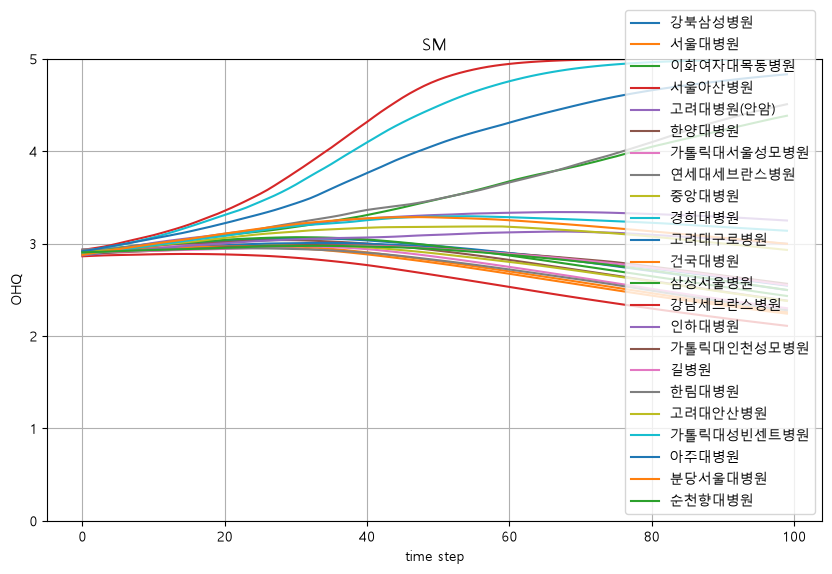

 20%|██        | 1/5 [00:00<00:00,  8.29it/s]

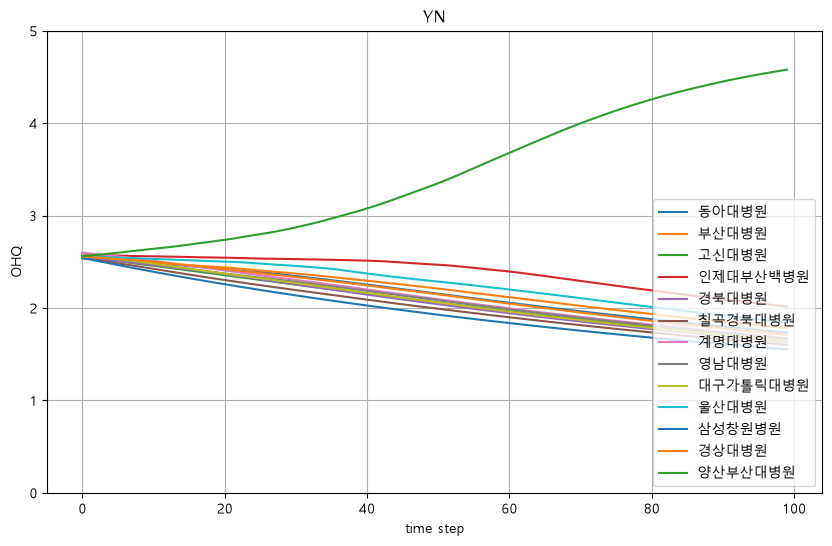

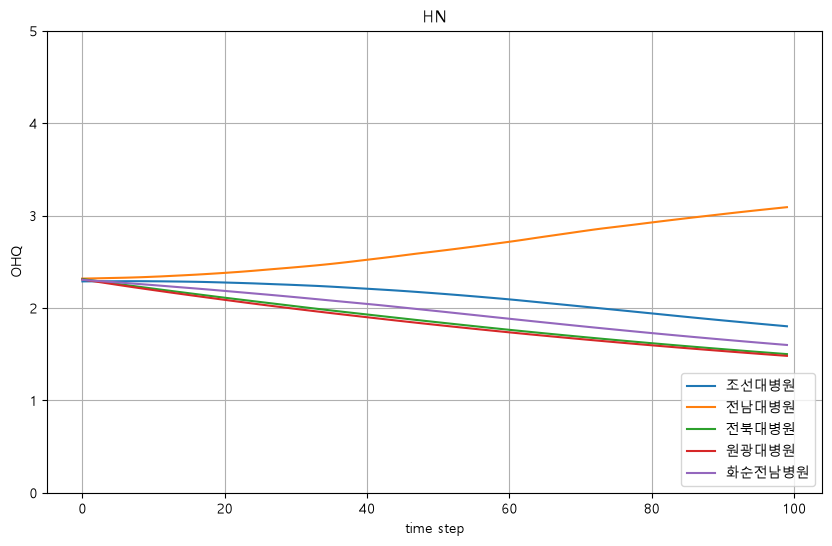

 60%|██████    | 3/5 [00:00<00:00, 11.78it/s]

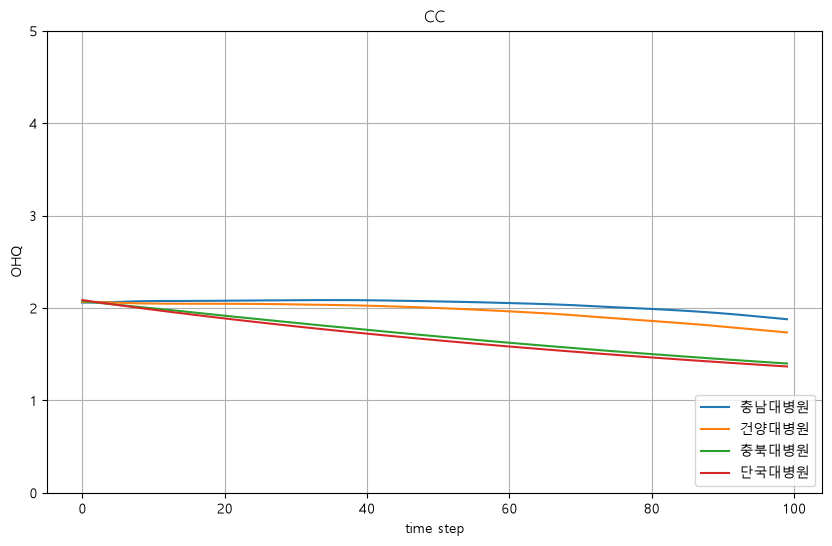

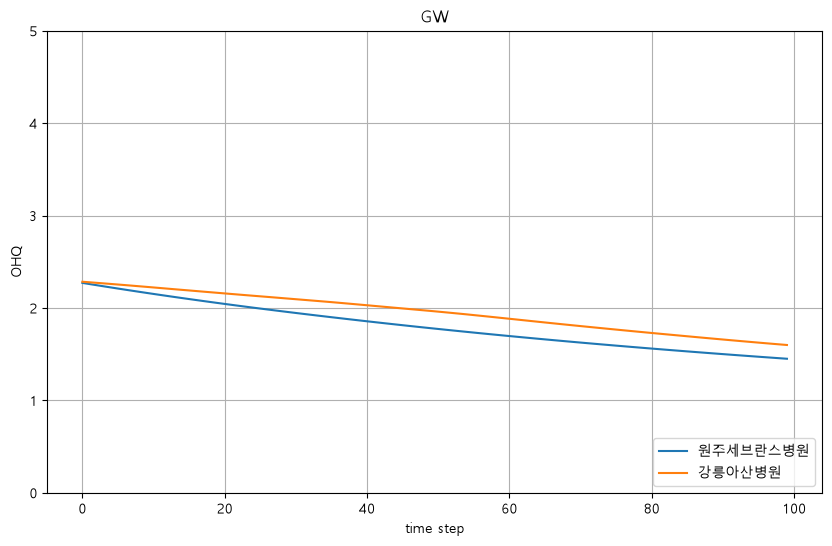

100%|██████████| 5/5 [00:00<00:00, 13.37it/s]


In [79]:
# OHQ in single region
for idx_region in tqdm(region_mapping.values()):
    nm_region = list(region_mapping.keys())[idx_region]
    list_idx_hospital = dict_target_idx_hospital[nm_region]

    plt.figure(figsize=(10, 6))

    for idx_hospital in list_idx_hospital:
        plt.plot(target_sim.achv_OHQ[:,idx_hospital]
                ,label=target_sim.df_Hospital_info.loc[target_sim.df_Hospital_info.idx_hospital == idx_hospital, 'nm_hospital'].values[0]) 
        
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.ylim(0,5)
    plt.title(list(region_mapping.keys())[idx_region])
    plt.xlabel("time step")
    plt.ylabel("OHQ")
    plt.show()

### Regional Average

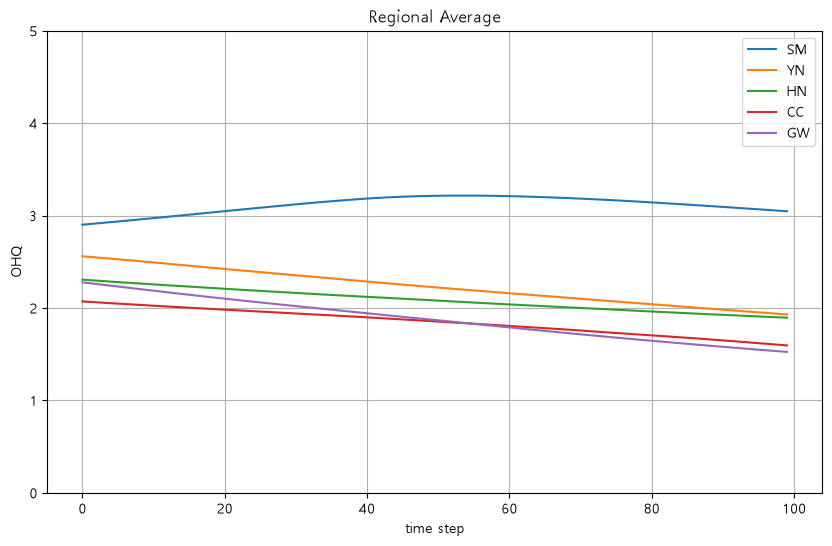

In [80]:
# mean OHQ for each region
plt.figure(figsize=(10, 6))

for key in dict_target_idx_hospital:
    plt.plot(np.mean(target_sim.achv_OHQ[:,dict_target_idx_hospital[key]], axis=1))
    
plt.legend(dict_target_idx_hospital.keys())
plt.grid(True)
plt.ylim(0,5)
plt.title("Regional Average")
plt.xlabel("time step")
plt.ylabel("OHQ")
plt.show()

## PRQ

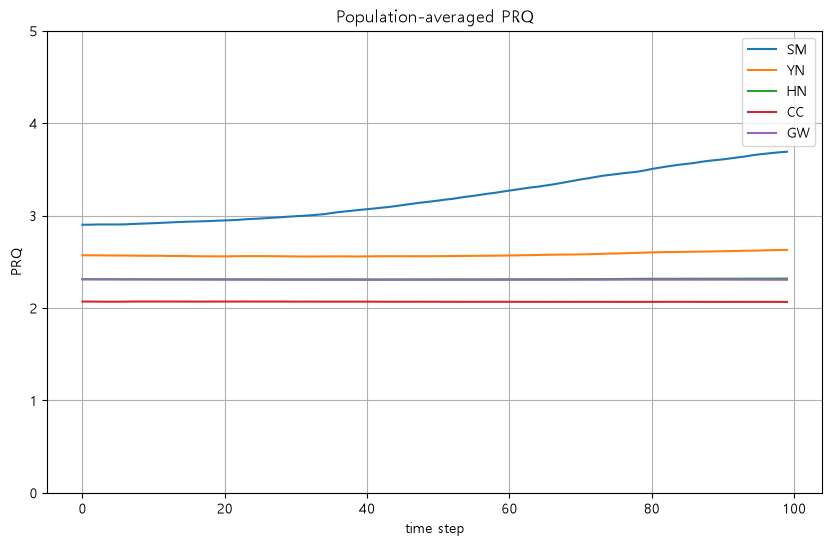

In [81]:
# PRQ
plt.figure(figsize=(10, 6))
temp = np.mean(target_sim.achv_population_PRQ, axis=1)

for i in range(temp.shape[1]):
    plt.plot(temp[:,i])
    
plt.legend(dict_target_idx_hospital.keys())
plt.grid(True)
plt.ylim(0,5)
plt.title("Population-averaged PRQ")
plt.xlabel("time step")
plt.ylabel("PRQ")
plt.show()

## PHQ

### Within each region

  0%|          | 0/5 [00:00<?, ?it/s]

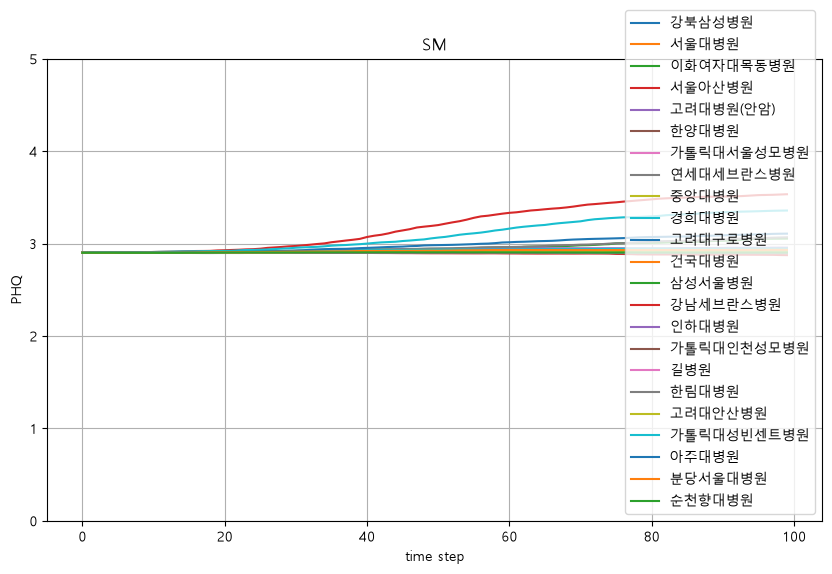

 20%|██        | 1/5 [00:00<00:01,  2.68it/s]

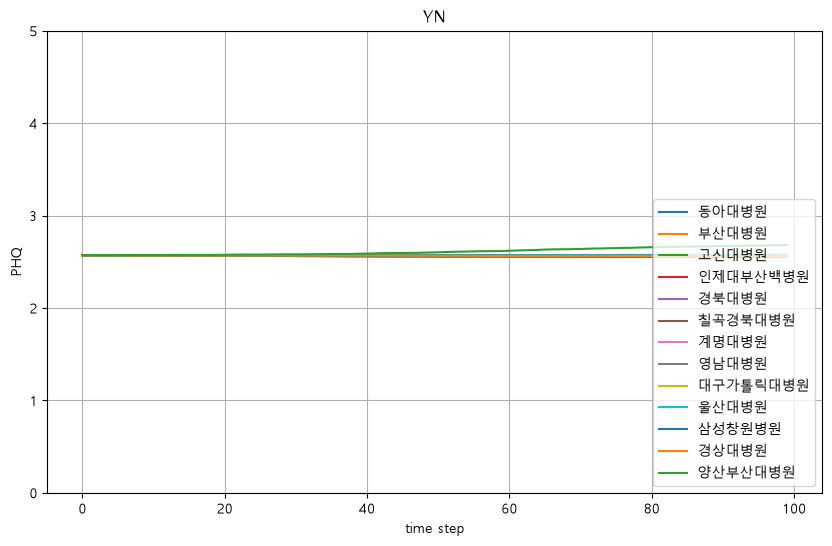

 40%|████      | 2/5 [00:00<00:00,  3.49it/s]

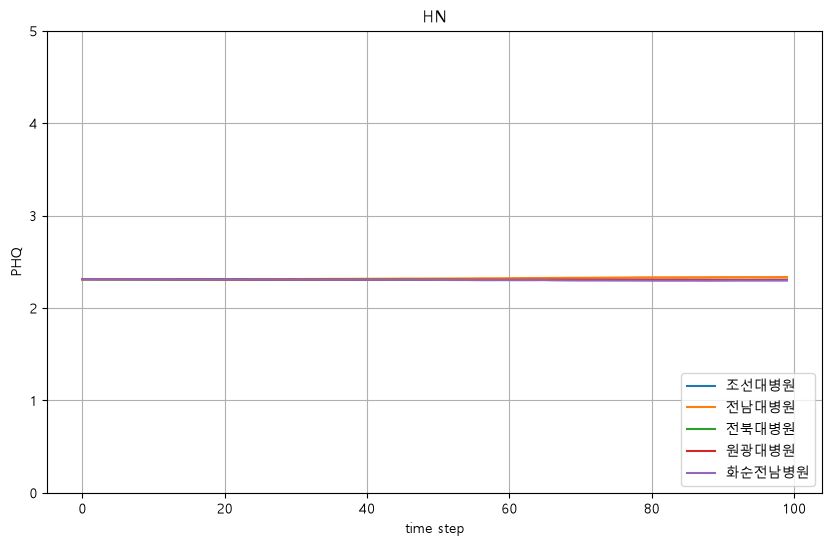

 60%|██████    | 3/5 [00:00<00:00,  4.83it/s]

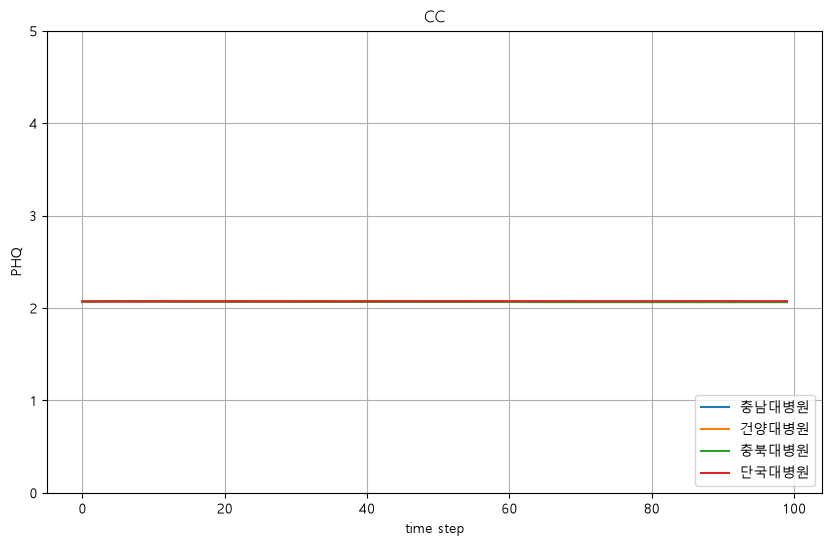

 80%|████████  | 4/5 [00:00<00:00,  5.99it/s]

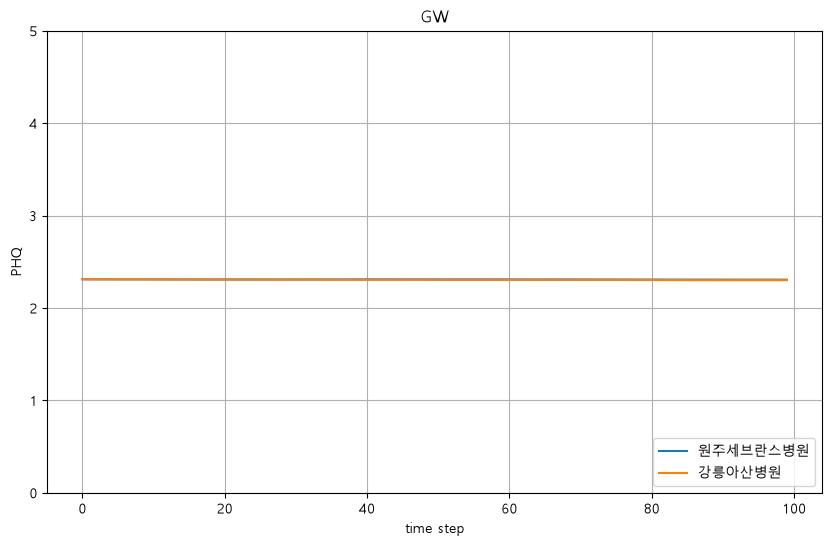

100%|██████████| 5/5 [00:00<00:00,  5.61it/s]


In [82]:
# PHQ in single region
for idx_region in tqdm(region_mapping.values()):
    nm_region = list(region_mapping.keys())[idx_region]
    list_idx_hospital = dict_target_idx_hospital[nm_region]

    plt.figure(figsize=(10, 6))

    for idx_hospital in list_idx_hospital:
        plt.plot(np.mean(target_sim.achv_population_PHQ, axis=1)[:,idx_hospital]
                ,label=target_sim.df_Hospital_info.loc[target_sim.df_Hospital_info.idx_hospital == idx_hospital, 'nm_hospital'].values[0]) 
        
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.ylim(0,5)
    plt.title(list(region_mapping.keys())[idx_region])
    plt.xlabel("time step")
    plt.ylabel("PHQ")
    plt.show()

### Regional Average

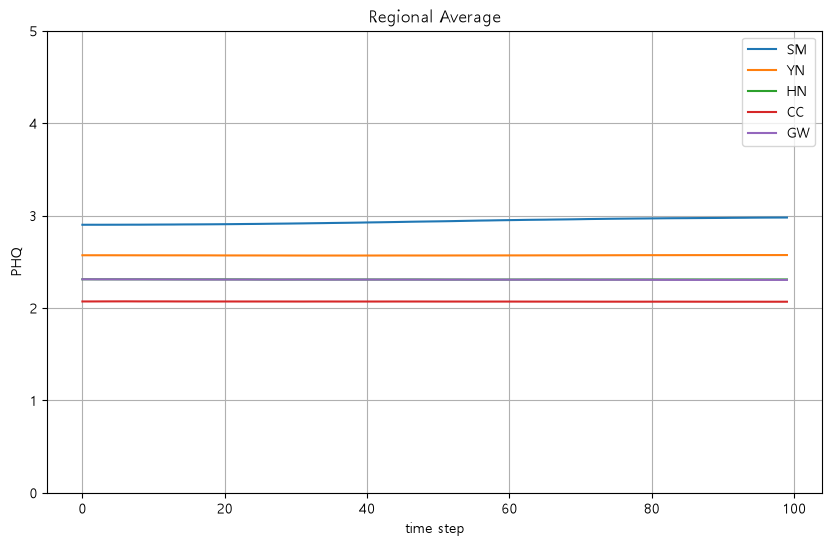

In [83]:
# mean PHQ for each region
plt.figure(figsize=(10, 6))

for key in dict_target_idx_hospital:
    plt.plot((np.mean(np.mean(target_sim.achv_population_PHQ[:,:,dict_target_idx_hospital[key]], axis=1), axis=1)))
    
plt.legend(dict_target_idx_hospital.keys())
plt.grid(True)
plt.ylim(0,5)
plt.title("Regional Average")
plt.xlabel("time step")
plt.ylabel("PHQ")
plt.show()

# Choice Probability

## Regional Choice Probability

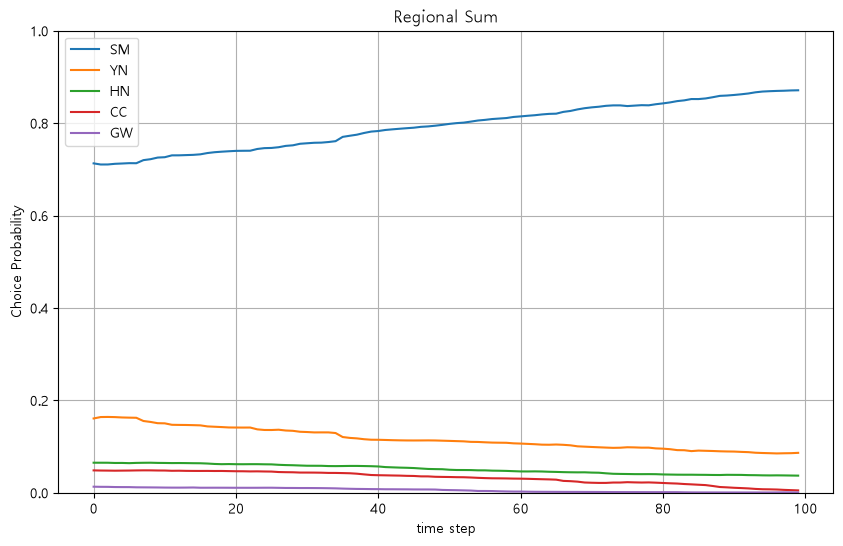

In [84]:
# Regional Choice Prob

plt.figure(figsize=(10, 6))

achv_choice_prob = np.mean(target_sim.achv_population_choice_prob, axis=1)

for idx_region in region_mapping.values():
    nm_region = list(region_mapping.keys())[idx_region]
    plt.plot(np.sum(achv_choice_prob[:,dict_target_idx_hospital[nm_region]], axis=1)
             , label=nm_region)  

plt.legend()
plt.grid(True)
plt.ylim(0,1)
plt.title("Regional Sum")
plt.xlabel("time step")
plt.ylabel("Choice Probability")
plt.show()

## Within each region

  0%|          | 0/5 [00:00<?, ?it/s]

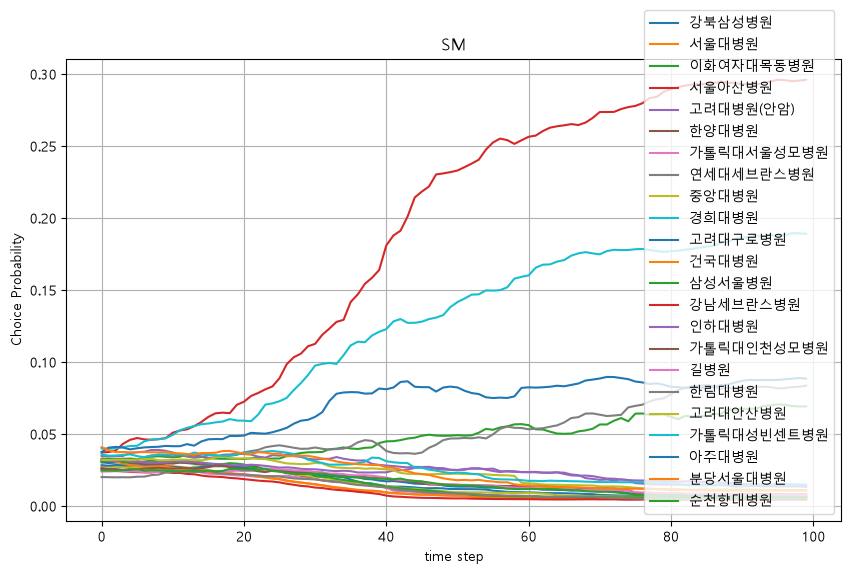

 20%|██        | 1/5 [00:00<00:00,  7.70it/s]

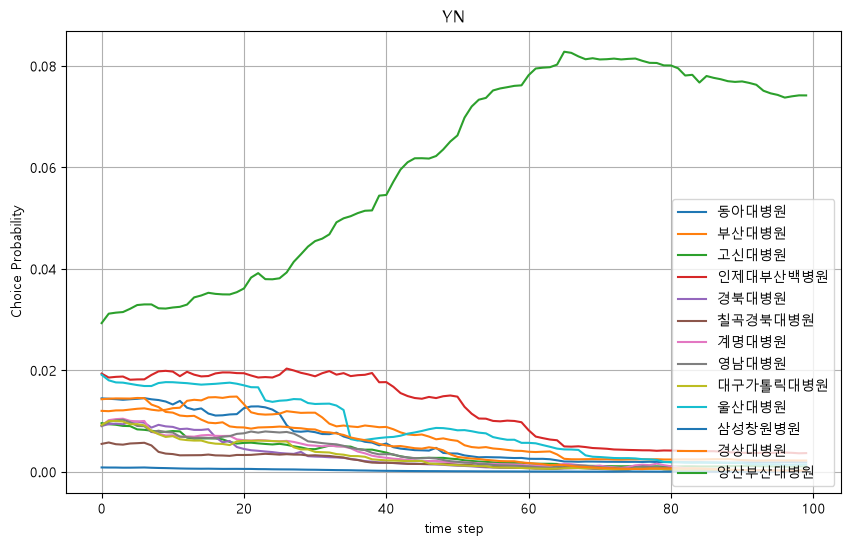

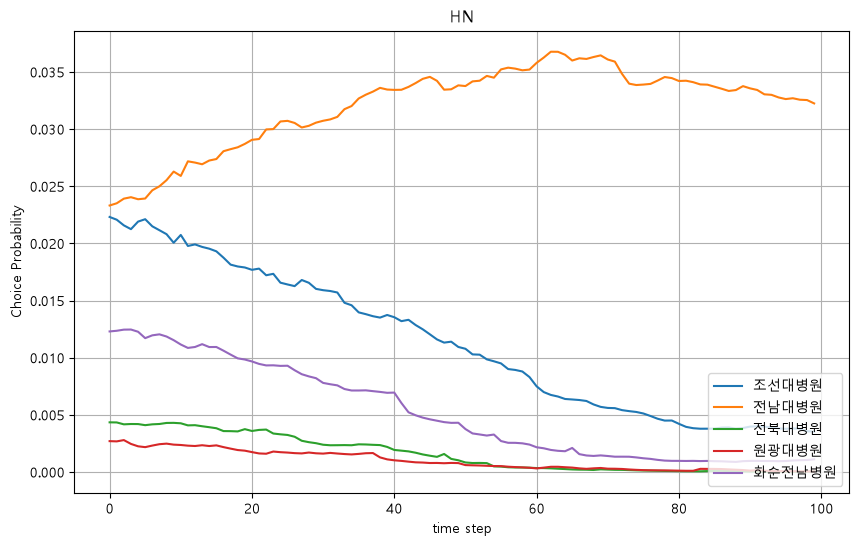

 60%|██████    | 3/5 [00:00<00:00, 10.35it/s]

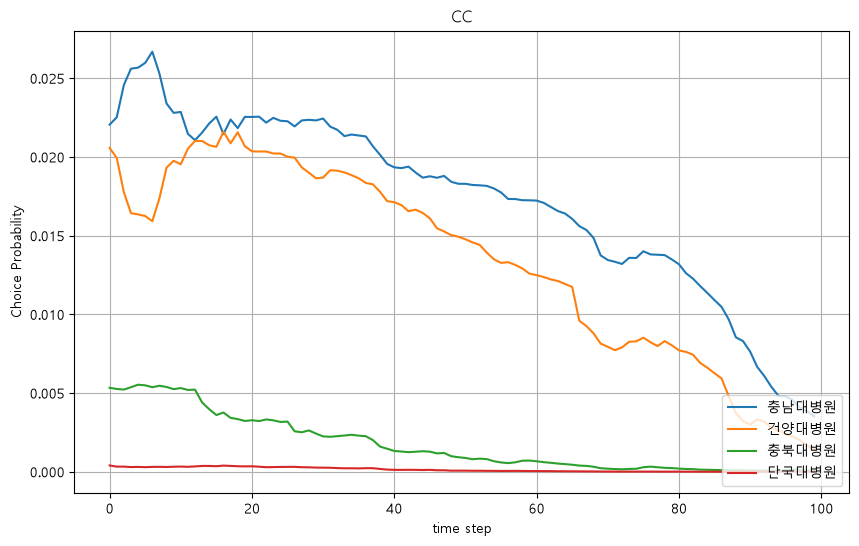

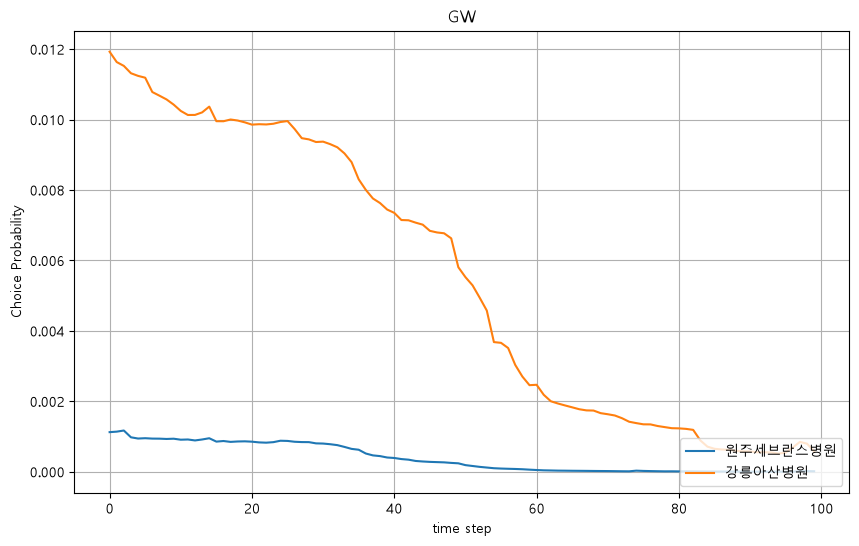

100%|██████████| 5/5 [00:00<00:00, 11.66it/s]


In [85]:
for idx_region in tqdm(region_mapping.values()):
    nm_region = list(region_mapping.keys())[idx_region]
    list_idx_hospital = dict_target_idx_hospital[nm_region]

    plt.figure(figsize=(10, 6))

    for idx_hospital in list_idx_hospital:
        plt.plot(achv_choice_prob[:,idx_hospital]
                ,label=target_sim.df_Hospital_info.loc[target_sim.df_Hospital_info.idx_hospital == idx_hospital, 'nm_hospital'].values[0])  

    plt.legend(loc='lower right')
    plt.grid(True)
    plt.title(list(region_mapping.keys())[idx_region])
    plt.xlabel("time step")
    plt.ylabel("Choice Probability")
    plt.show()

## Outmigration Probability

In [86]:
dict_regional_choice_prob = {}
for idx_region in region_mapping.values():
    region = list(region_mapping.keys())[idx_region]
    dict_regional_choice_prob[idx_region] = np.mean(target_sim.achv_population_choice_prob[:,
                                        target_sim.df_Person_info.loc[target_sim.df_Person_info.REGION==region].idx_person.values,
                                        :], axis=1)

### Entire Population

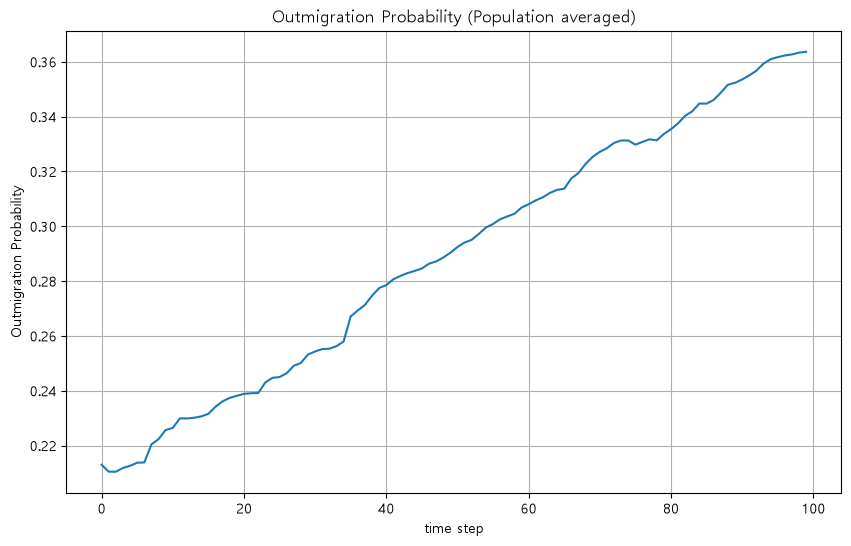

In [87]:
prob_outmigration = np.zeros((parameter_set_simulation.max_dt, 5))
for idx_region in range(5):
    prob_outmigration[:, idx_region] = np.sum(dict_regional_choice_prob[idx_region][:, np.array(range(47))[~np.isin(np.array(range(47)), dict_target_idx_hospital[list(region_mapping.keys())[idx_region]])]], axis=1)

prob_outmigration_population_averaged = np.dot(prob_outmigration, target_sim.df_Person_info.groupby("idx_REGION").size().values / len(target_sim.df_Person_info))

plt.figure(figsize=(10, 6))
plt.plot(prob_outmigration_population_averaged)
plt.grid(True)
plt.title("Outmigration Probability (Population averaged)")
plt.xlabel("time step")
plt.ylabel("Outmigration Probability")
plt.show()


## For each region

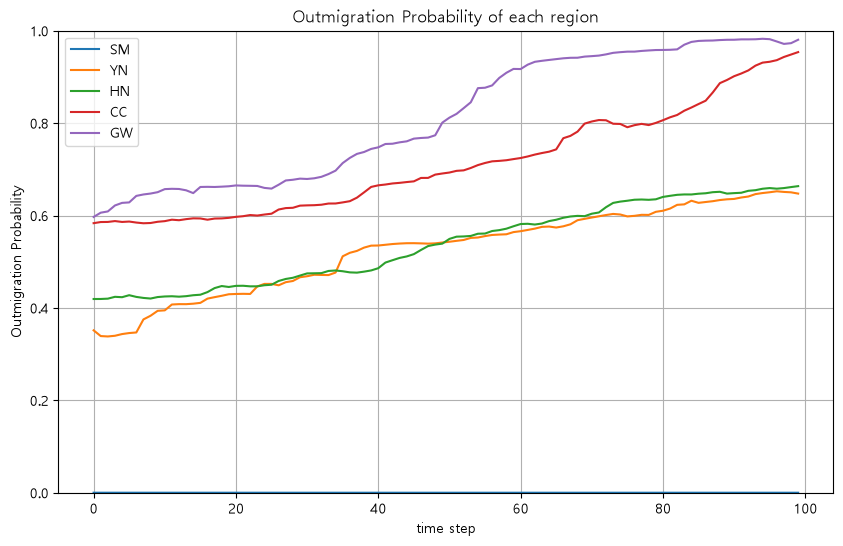

In [88]:
plt.figure(figsize=(10, 6))
plt.plot(prob_outmigration, label = region_mapping.keys())
plt.legend()
plt.grid(True)
plt.ylim(0,1)
plt.title("Outmigration Probability of each region")
plt.xlabel("time step")
plt.ylabel("Outmigration Probability")
plt.show()